# Autonomous Drone Rescue Using Dynamic Programming

---

| Field | Value |
|---|---|
| **Assignment** | Dynamic Programming — Value Iteration |
| **Group ID** | 239 |
| **Register Number** | 2024ac05884 |
| **Total Marks** | 5 |
| **Algorithm** | Value Iteration (Finite MDP) |

---

## Objective

Design and implement a reinforcement learning agent using **Dynamic Programming (Value Iteration)** to compute an optimal policy for an autonomous rescue drone in a disaster zone, modelled as a **finite Markov Decision Process (MDP)**.

The drone must:
- Rescue stranded civilians
- Manage battery power
- Avoid dangerous zones
- Use charging stations before battery depletion

---
## Section 1 — Environment Setup
### 1.1 Imports

In [1]:
# Standard library imports
import random      # For stochastic wind simulation in the environment
import time        # For measuring Value Iteration runtime
import copy        # For deep-copying state dicts during VI

# Numerical and visualisation libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from collections import defaultdict

# Fix random seeds for reproducibility
SEED = 239   # Group ID used as deterministic seed for grid placement
random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully.")
print(f"Random seed set to: {SEED}")

All libraries imported successfully.
Random seed set to: 239


---
### 1.2 Grid Configuration

#### Derivation from Group ID 239

**Step 1 — Determine grid size:**  
Group ID 239 ends in **9** (range 5–9) → **6×6 grid**

**Step 2 — Determine cell counts:**  
Group ID ends in 5–9 → **3 Rescue targets, 2 Charging stations, 4 Danger zones, 3 Blocked cells**  
Wind zones (2) are included per the spec; count chosen conservatively.

**Step 3 — Determine max battery:**  
Group ID 239 ends in **9** (odd) → **max battery = 15 units**

**Step 4 — Determine wind probability:**  
Group ID ends in 5–9 → **wind probability = 30%**

**Step 5 — Derive cell placement from Group ID:**  
Group ID `239` is used directly as the integer seed: `random.seed(239)`.  
All 35 non-start positions are shuffled with this seed.  
First 14 shuffled positions are assigned in order: **3R → 2C → 4D → 3X → 2W**.  
Remaining 21 positions are free cells (F).

#### Resulting 6×6 Grid

```
     Col: 0    1    2    3    4    5
Row 0:   [ S ][ F ][ F ][ F ][ F ][ F ]
Row 1:   [ X ][ D ][ F ][ F ][ F ][ D ]
Row 2:   [ F ][ F ][ F ][ X ][ W ][ R ]
Row 3:   [ F ][ F ][ F ][ W ][ C ][ D ]
Row 4:   [ F ][ F ][ F ][ F ][ D ][ R ]
Row 5:   [ F ][ F ][ C ][ F ][ R ][ X ]
```

| Symbol | Meaning | Positions |
|--------|---------|----------|
| **S** | Start (top-left, fixed) | (0,0) |
| **R** | Rescue target | (2,5), (4,5), (5,4) |
| **C** | Charging station | (3,4), (5,2) |
| **D** | Danger zone | (1,1), (1,5), (3,5), (4,4) |
| **X** | Blocked cell | (1,0), (2,3), (5,5) |
| **W** | Wind zone | (2,4), (3,3) |
| **F** | Free/safe cell | all remaining |

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# GRID LAYOUT & CONSTANTS
# Derived deterministically from Group ID 239 (used directly as random seed = 239)
# ──────────────────────────────────────────────────────────────────────────────

# Grid dimensions (6×6 because Group ID 239 ends in 9, range 5-9)
NROWS = 6
NCOLS = 6

# Base grid: each inner list is one row, each element is a cell symbol
# S=Start, F=Free, R=Rescue, C=Charge, D=Danger, W=Wind, X=Blocked
# Layout: random.seed(239), shuffle 35 non-start positions,
# assign first 14 as 3R → 2C → 4D → 3X → 2W (see markdown grid above)
GRID_BASE = [
    ['S', 'F', 'F', 'F', 'F', 'F'],   # Row 0
    ['X', 'D', 'F', 'F', 'F', 'D'],   # Row 1
    ['F', 'F', 'F', 'X', 'W', 'R'],   # Row 2
    ['F', 'F', 'F', 'W', 'C', 'D'],   # Row 3
    ['F', 'F', 'F', 'F', 'D', 'R'],   # Row 4
    ['F', 'F', 'C', 'F', 'R', 'X'],   # Row 5
]

# ── Cell type lookup sets (for O(1) membership queries) ───────────────────────

# Rescue target positions (ordered: bit 0, bit 1, bit 2 in the rescue bitmask)
RESCUE_POSITIONS  = [(2, 5), (4, 5), (5, 4)]

# Charging station positions
CHARGE_POSITIONS  = {(3, 4), (5, 2)}

# Danger zone positions
DANGER_POSITIONS  = {(1, 1), (1, 5), (3, 5), (4, 4)}

# Blocked/obstacle positions — drone CANNOT enter these
BLOCKED_POSITIONS = {(1, 0), (2, 3), (5, 5)}

# Wind zone positions — stochastic movement (30% random redirect)
WIND_POSITIONS    = {(2, 4), (3, 3)}

# Derived rescue mask constants
NUM_RESCUES = len(RESCUE_POSITIONS)   # 3 rescue targets
FULL_MASK   = (1 << NUM_RESCUES) - 1  # 0b111 = 7 (all targets rescued)

# ── MDP Parameters ────────────────────────────────────────────────────────────

# Max battery = 15 (Group ID 239 ends in 9, which is ODD → 15 units)
MAX_BATTERY = 15

# Wind disturbance probability = 30% (Group ID 239 ends in 5-9 range)
WIND_PROB   = 0.30

# Max steps per episode = 75 (for 6×6 grid)
MAX_STEPS   = 75

# Start position: always top-left corner (fixed per specification)
START_POS   = (0, 0)

# ── Action definitions ────────────────────────────────────────────────────────

UP, DOWN, LEFT, RIGHT, HOVER = 0, 1, 2, 3, 4   # Action indices
ACTIONS = [UP, DOWN, LEFT, RIGHT, HOVER]         # Full action set

# Human-readable names for printing
ACTION_NAMES = {UP: 'UP', DOWN: 'DOWN', LEFT: 'LEFT', RIGHT: 'RIGHT', HOVER: 'HOVER'}

# Unicode arrows for policy visualisation
ACTION_ARROWS = {UP: '↑', DOWN: '↓', LEFT: '←', RIGHT: '→', HOVER: '●'}

# (row_delta, col_delta) for each movement action
ACTION_DELTA = {
    UP:    (-1,  0),   # Move north: row decreases
    DOWN:  (+1,  0),   # Move south: row increases
    LEFT:  ( 0, -1),   # Move west:  col decreases
    RIGHT: ( 0, +1),   # Move east:  col increases
    HOVER: ( 0,  0),   # Stay in place
}

# ── Reward values (per specification) ─────────────────────────────────────────
R_RESCUE       = +20   # Rescuing a stranded civilian
R_DANGER       = -10   # Entering a fire/radiation/danger zone
R_BATTERY_DEAD = -20   # Battery drops to zero (terminal penalty)
R_CHARGE_ENTRY = +5    # Entering a charging station (battery refilled)
R_MOVE         = -1    # Any regular movement or hover (not on C)

# ── DP Hyperparameters ────────────────────────────────────────────────────────
GAMMA = 0.99    # Discount factor: high value to incentivise long-term rescue
THETA = 1e-3    # Convergence threshold for Value Iteration

# ── Summary printout ──────────────────────────────────────────────────────────
print("=" * 55)
print("  ENVIRONMENT CONFIGURATION (Group ID 239)")
print("=" * 55)
print(f"  Grid size         : {NROWS} × {NCOLS}")
print(f"  Rescue targets    : {RESCUE_POSITIONS}  (3 targets)")
print(f"  Charging stations : {sorted(CHARGE_POSITIONS)}")
print(f"  Danger zones      : {sorted(DANGER_POSITIONS)}")
print(f"  Blocked cells     : {sorted(BLOCKED_POSITIONS)}")
print(f"  Wind zones        : {sorted(WIND_POSITIONS)}")
print(f"  Max battery       : {MAX_BATTERY} units")
print(f"  Wind probability  : {int(WIND_PROB*100)}%")
print(f"  Max steps/episode : {MAX_STEPS}")
print(f"  Start position    : {START_POS}")
print(f"  Discount γ        : {GAMMA}")
print(f"  VI threshold θ    : {THETA}")
print("=" * 55)

  ENVIRONMENT CONFIGURATION (Group ID 239)
  Grid size         : 6 × 6
  Rescue targets    : [(2, 5), (4, 5), (5, 4)]  (3 targets)
  Charging stations : [(3, 4), (5, 2)]
  Danger zones      : [(1, 1), (1, 5), (3, 5), (4, 4)]
  Blocked cells     : [(1, 0), (2, 3), (5, 5)]
  Wind zones        : [(2, 4), (3, 3)]
  Max battery       : 15 units
  Wind probability  : 30%
  Max steps/episode : 75
  Start position    : (0, 0)
  Discount γ        : 0.99
  VI threshold θ    : 0.001


---
### 1.3 Shared Helper Functions

These module-level helper functions are used by **both** the simulation environment and the DP transition model to ensure complete consistency between the two.

- `effective_cell(r, c, mask)` — resolves a cell's type accounting for rescued targets  
- `apply_action_to_pos(r, c, action)` — computes the new position after an action  
- `compute_outcome(r, c, bat, mask, action)` — the deterministic MDP transition kernel

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# SHARED HELPER FUNCTIONS
# Used by both DroneRescueEnv (simulation) and get_transitions() (DP model)
# ──────────────────────────────────────────────────────────────────────────────

def effective_cell(r, c, mask):
    """
    Return the effective cell type at (r, c) given the current rescue mask.

    Rescue targets that have already been collected (their bitmask bit is set)
    are treated as free cells 'F', because the civilian has been rescued and
    the cell no longer provides any rescue reward.
    The start cell 'S' is treated as 'F' for reward-computation purposes.

    Args:
        r, c (int) : Grid row and column
        mask (int) : Rescue bitmask (bit i = 1 means RESCUE_POSITIONS[i] is done)

    Returns:
        str: Effective cell type symbol
    """
    base = GRID_BASE[r][c]

    # Start cell treated as free for reward purposes
    if base == 'S':
        return 'F'

    # Rescue target: check if already collected via bitmask
    if base == 'R':
        idx = RESCUE_POSITIONS.index((r, c))
        if mask & (1 << idx):          # Bit is set → target already rescued
            return 'F'                 # Cell is now free

    return base


def apply_action_to_pos(r, c, action):
    """
    Compute the drone's new (row, col) after applying an action.

    Handles three cases:
    1. HOVER: position unchanged
    2. Movement to out-of-bounds: position unchanged (drone stays)
    3. Movement into blocked cell (X): position unchanged (drone stays)
    In cases 2 and 3 the action still consumes 1 battery unit.

    Args:
        r, c   (int) : Current drone position
        action (int) : Action index (UP/DOWN/LEFT/RIGHT/HOVER)

    Returns:
        tuple: (new_row, new_col) — may equal (r, c) if movement is invalid
    """
    if action == HOVER:
        return (r, c)   # Hover: no positional change

    dr, dc = ACTION_DELTA[action]
    nr, nc = r + dr, c + dc

    # Boundary check: stay if out of grid
    if not (0 <= nr < NROWS and 0 <= nc < NCOLS):
        return (r, c)

    # Blocked cell check: stay if destination is an obstacle
    if (nr, nc) in BLOCKED_POSITIONS:
        return (r, c)

    return (nr, nc)   # Valid move


def compute_outcome(r, c, bat, mask, action):
    """
    Compute the deterministic outcome of executing `action` from state (r,c,bat,mask).

    This is the core MDP transition kernel. It is called once per (action, probability)
    pair in get_transitions() to build the full stochastic model.

    Reward priority (checked in order):
    1. Hover on C   → R_MOVE (-1),           battery += 2 (capped at MAX)
    2. Enter C      → R_CHARGE_ENTRY (+5),   battery = MAX_BATTERY
    3. Enter R      → R_RESCUE (+20),         rescue mask updated
    4. Enter D      → R_DANGER (-10),         only on actual movement
    5. Default      → R_MOVE (-1)

    If new battery <= 0 after the action: add R_BATTERY_DEAD (-20) penalty.

    Args:
        r, c   (int) : Current drone position
        bat    (int) : Current battery level (>= 1, caller ensures non-terminal)
        mask   (int) : Current rescue bitmask
        action (int) : Action to evaluate (deterministic, post-wind)

    Returns:
        next_state (tuple) : (new_r, new_c, new_bat, new_mask)
        reward     (float) : Reward for this transition
    """
    # --- Compute positional result ---
    nr, nc         = apply_action_to_pos(r, c, action)
    actually_moved = (nr, nc) != (r, c)   # True if drone physically changed position
    eff            = effective_cell(nr, nc, mask)  # Effective cell at destination

    new_mask = mask
    reward   = 0.0

    # --- Case 1: Hovering on a Charging Station ---
    # Battery increases by +2 (capped); action still costs -1 reward
    if action == HOVER and (r, c) in CHARGE_POSITIONS:
        new_bat = min(bat + 2, MAX_BATTERY)   # +2 battery, cannot exceed maximum
        reward  = R_MOVE                       # Standard hover cost

    else:
        # All other actions consume exactly 1 battery unit
        new_bat = bat - 1

        # --- Case 2: Entering a Charging Station (by movement) ---
        if actually_moved and (nr, nc) in CHARGE_POSITIONS:
            new_bat = MAX_BATTERY   # Battery refilled to maximum on entry
            reward  = R_CHARGE_ENTRY

        # --- Case 3: Reaching an unrescued Rescue Target ---
        elif eff == 'R':
            idx      = RESCUE_POSITIONS.index((nr, nc))
            new_mask = mask | (1 << idx)   # Set the corresponding bitmask bit
            reward   = R_RESCUE

        # --- Case 4: Entering a Danger Zone (only penalised on entry, not hover) ---
        elif eff == 'D' and actually_moved:
            reward = R_DANGER

        # --- Case 5: Regular movement (free cells, hovering, wall collisions) ---
        else:
            reward = R_MOVE

    # --- Battery exhaustion penalty (additive, applied on top of step reward) ---
    if new_bat <= 0:
        new_bat  = 0            # Clamp battery to zero
        reward  += R_BATTERY_DEAD   # Additional -20 penalty for running out

    next_state = (nr, nc, new_bat, new_mask)
    return next_state, reward


# ── Quick unit tests for helper functions ─────────────────────────────────────
print("Helper function unit tests:")
print()

# Test effective_cell: rescued target should return 'F'
assert effective_cell(2, 5, 0b001) == 'F',  "Rescued R0 should show as F"
assert effective_cell(2, 5, 0b000) == 'R',  "Unrescued R0 should show as R"
assert effective_cell(0, 0, 0b000) == 'F',  "Start cell S should show as F"
assert effective_cell(1, 1, 0b000) == 'D',  "Danger cell should show as D"
print("  [PASS] effective_cell(): rescued targets → 'F', S → 'F', others correct")

# Test apply_action_to_pos: blocked/OOB should return same position
assert apply_action_to_pos(0, 0, UP)   == (0, 0), "UP from top row should stay"
assert apply_action_to_pos(0, 3, RIGHT) == (0, 4), "Move to (0,4) should succeed"
assert apply_action_to_pos(2, 4, LEFT) == (2, 4), "Move into X at (2,3) should stay"
print("  [PASS] apply_action_to_pos(): out-of-bounds and blocked correctly handled")

# Test compute_outcome: entering C should refill battery
ns, r = compute_outcome(5, 1, 5, 0, RIGHT)  # Move from (5,1) → (5,2) which is C
assert ns[2] == MAX_BATTERY, "Entering C should refill battery to MAX"
assert r == R_CHARGE_ENTRY, "Entering C should give R_CHARGE_ENTRY reward"
print("  [PASS] compute_outcome(): entering C gives full battery + +5 reward")

# Test compute_outcome: rescue target
ns, r = compute_outcome(2, 4, 15, 0, RIGHT)  # Move from (2,4) → (2,5) which is R
assert ns[3] == 0b001, "Rescue bit 0 should be set"
assert r == R_RESCUE, "Rescue reward should be +20"
print("  [PASS] compute_outcome(): rescue target sets bit and gives +20 reward")

print()
print("All helper function tests passed.")

Helper function unit tests:

  [PASS] effective_cell(): rescued targets → 'F', S → 'F', others correct
  [PASS] apply_action_to_pos(): out-of-bounds and blocked correctly handled
  [PASS] compute_outcome(): entering C gives full battery + +5 reward
  [PASS] compute_outcome(): rescue target sets bit and gives +20 reward

All helper function tests passed.


---
### 1.4 Custom Drone Rescue Environment

The `DroneRescueEnv` class implements the **simulation interface** for the rescue drone:

- `reset()` — Initialises the episode, returns the start state
- `step(action)` — Applies an action, returns `(next_state, reward, done, info)`
- `render(state)` — Prints an ASCII-art view of the grid
- `get_valid_actions(state)` — Returns valid actions from a state

**State representation:** `(row, col, battery, rescue_mask)`
- `row, col` — drone position on the 6×6 grid (0-indexed)
- `battery` — current battery level (integer, 0 to 15)
- `rescue_mask` — integer bitmask for 3 targets: bit $i$ = 1 means target $i$ rescued
  - `0b000` = no rescues, `0b111` = all 3 rescued

**Transition dynamics:**
- Battery: every action consumes 1 unit, except hovering on C which adds +2
- Wind: 30% chance of random direction when on a W cell (movement only)
- Rescue: target removed (mask updated) on first arrival, reward +20
- Charging: battery set to full on entry (+5 reward); hover on C adds +2
- Danger: −10 reward on entry (episode continues)
- Blocked/OOB: drone stays, 1 battery consumed

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# CUSTOM DRONE RESCUE ENVIRONMENT
# ──────────────────────────────────────────────────────────────────────────────

class DroneRescueEnv:
    """
    Custom Autonomous Drone Rescue Environment — Finite MDP.

    Models a 6×6 disaster-zone grid where a rescue drone must navigate to save
    civilians, manage battery, and avoid dangerous areas. The environment is
    designed as a finite MDP with stochastic wind transitions.

    State Space (row, col, battery, rescue_mask):
        row, col      : Drone position — 6×6 grid (0-indexed)
        battery       : Current battery level — integers 0 to MAX_BATTERY (15)
        rescue_mask   : Bitmask over 3 rescue targets — integers 0 to 7

    Theoretical state count: 33 valid positions × 16 battery levels × 8 masks = 4,224
    (33 = 36 total cells − 3 blocked cells)

    Action Space:
        UP(0), DOWN(1), LEFT(2), RIGHT(3), HOVER(4)

    Episode Termination:
        1. Battery reaches 0 (dead)
        2. All rescue targets collected (mask == 0b111 == 7)
        3. Step count exceeds MAX_STEPS (75)
    """

    def __init__(self):
        """
        Initialise the environment.

        Builds a cell-type lookup dictionary for fast O(1) access during
        simulation. Internal state variables are set to None until reset().
        """
        self.nrows       = NROWS
        self.ncols       = NCOLS
        self.max_battery = MAX_BATTERY
        self.wind_prob   = WIND_PROB
        self.max_steps   = MAX_STEPS

        # Build a flat dict mapping (row, col) → cell symbol for quick lookup
        self.cell_map = {
            (r, c): GRID_BASE[r][c]
            for r in range(NROWS)
            for c in range(NCOLS)
        }

        # Internal episode state (None until reset() is called)
        self.pos         = None
        self.battery     = None
        self.rescue_mask = None
        self.steps       = None

    # ──────────────────────────────────────────────────────────────────────────
    # Core MDP Interface
    # ──────────────────────────────────────────────────────────────────────────

    def reset(self):
        """
        Reset the environment to its initial state.

        The drone starts at position (0,0) — the top-left corner — with a
        full battery of 15 units and no rescue targets collected yet.

        Returns:
            state (tuple): Initial state (row=0, col=0, battery=15, mask=0)
        """
        self.pos         = START_POS     # Fixed top-left start per specification
        self.battery     = MAX_BATTERY   # Start with full battery
        self.rescue_mask = 0             # No rescue targets collected
        self.steps       = 0             # Step counter reset
        return self._get_state()

    def step(self, action):
        """
        Execute one step in the environment given an action.

        Transition sequence:
          1. Wind disturbance check (if on W cell and not hovering: 30% redirect)
          2. Compute new position via apply_action_to_pos()
          3. Compute new battery, new mask, and reward via compute_outcome()
          4. Update internal state
          5. Check terminal conditions

        Args:
            action (int): One of UP(0), DOWN(1), LEFT(2), RIGHT(3), HOVER(4)

        Returns:
            next_state (tuple): (row, col, battery, rescue_mask) after transition
            reward     (float): Reward received this step
            done       (bool) : True if the episode has ended
            info       (dict) : Diagnostics — 'reason' key if done, 'wind_redirected'
                                if wind changed the direction, 'rescued' if rescue done
        """
        r, c  = self.pos
        done  = False
        info  = {}

        # ── Step 1: Wind disturbance ──────────────────────────────────────────
        # Wind only affects movement actions (hover is immune to wind)
        if self.cell_map.get((r, c)) == 'W' and action != HOVER:
            if random.random() < self.wind_prob:
                # 30% chance: replace intended direction with uniform random choice
                action = random.choice([UP, DOWN, LEFT, RIGHT])
                info['wind_redirected'] = True

        # ── Step 2: Compute outcome using shared helper ───────────────────────
        # compute_outcome handles: position update, battery, reward, rescue mask
        next_state, reward = compute_outcome(r, c, self.battery, self.rescue_mask, action)
        nr, nc, new_bat, new_mask = next_state

        # Track rescue events for info dict
        if new_mask != self.rescue_mask:
            # Find which target was newly rescued
            diff = new_mask ^ self.rescue_mask
            for i in range(NUM_RESCUES):
                if diff & (1 << i):
                    info['rescued'] = RESCUE_POSITIONS[i]

        # ── Step 3: Update internal state ────────────────────────────────────
        self.pos         = (nr, nc)
        self.battery     = new_bat
        self.rescue_mask = new_mask
        self.steps      += 1

        # ── Step 4: Terminal conditions ───────────────────────────────────────
        if self.battery <= 0:
            # Battery dead: episode ends immediately
            done = True
            info['reason'] = 'battery_exhausted'

        elif self.rescue_mask == FULL_MASK:
            # All 3 rescue targets collected: mission success
            done = True
            info['reason'] = 'all_rescued'

        elif self.steps >= self.max_steps:
            # Episode time limit exceeded
            done = True
            info['reason'] = 'max_steps_exceeded'

        return self._get_state(), reward, done, info

    def get_valid_actions(self, state):
        """
        Return the list of valid actions available from a given state.

        Per the specification, all 5 actions are always available from every
        non-terminal state. Movement into blocked/OOB cells is 'valid' but
        physically ineffective (drone stays, battery still consumed).

        Args:
            state (tuple): (row, col, battery, rescue_mask)

        Returns:
            list: All 5 actions for non-terminal states; empty list for terminal.
        """
        _, _, battery, mask = state
        if battery == 0 or mask == FULL_MASK:
            return []            # Terminal state: no actions available
        return list(ACTIONS)     # All 5 actions valid in any live state

    def render(self, state=None):
        """
        Render the grid state as a formatted ASCII display.

        The drone's current position is marked with '*'. Rescue targets that
        have been collected are shown as 'F'. Battery and rescue status are
        displayed in the header.

        Args:
            state (tuple, optional): State to render. Uses current env state if None.
        """
        if state is None:
            r, c, bat, mask = self._get_state()
        else:
            r, c, bat, mask = state

        # Build rescue status: checkmark if rescued, cross if not
        rescue_parts = []
        for i in range(NUM_RESCUES):
            status = 'R' + str(i) + ('✓' if (mask & (1 << i)) else '✗')
            rescue_parts.append(status)
        rescue_str = '  '.join(rescue_parts)

        # Header
        print('+' + '-' * 31 + '+')
        print(f'|  Drone Rescue Grid (6x6)         |')
        print(f'|  Battery: {bat:2d}/{MAX_BATTERY}  {rescue_str}  |')
        print(f'|  Steps: {self.steps if self.steps is not None else 0:<23}|')
        print('+' + '-' * 31 + '+')
        print('|    ' + '  '.join(str(j) for j in range(NCOLS)) + '        |')

        # Grid rows
        for row in range(self.nrows):
            line = f'| {row} | '
            for col in range(self.ncols):
                if (row, col) == (r, c):
                    line += '* '   # Mark drone position
                else:
                    cell = effective_cell(row, col, mask)
                    line += f'{cell} '
            line += '|'
            print(line)

        print('+' + '-' * 31 + '+')
        print('  S=Start F=Free R=Rescue C=Charge D=Danger W=Wind X=Blocked *=Drone')
        print()

    # ──────────────────────────────────────────────────────────────────────────
    # Private helpers
    # ──────────────────────────────────────────────────────────────────────────

    def _get_state(self):
        """
        Build and return the current state tuple.

        Returns:
            tuple: (row, col, battery, rescue_mask)
        """
        return (self.pos[0], self.pos[1], self.battery, self.rescue_mask)


# ── Environment smoke-test ─────────────────────────────────────────────────────
env = DroneRescueEnv()
s0  = env.reset()

print("Environment initialised. Initial state:", s0)
print(f"  Position : ({s0[0]}, {s0[1]})")
print(f"  Battery  : {s0[2]}/{MAX_BATTERY}")
print(f"  Mask     : {bin(s0[3])[2:].zfill(NUM_RESCUES)} (no rescues yet)")
print()
print("Valid actions from start state:", [ACTION_NAMES[a] for a in env.get_valid_actions(s0)])
print()

# Render the initial grid
env.render()

Environment initialised. Initial state: (0, 0, 15, 0)
  Position : (0, 0)
  Battery  : 15/15
  Mask     : 000 (no rescues yet)

Valid actions from start state: ['UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER']

+-------------------------------+
|  Drone Rescue Grid (6x6)         |
|  Battery: 15/15  R0✗  R1✗  R2✗  |
|  Steps: 0                      |
+-------------------------------+
|    0  1  2  3  4  5        |
| 0 | * F F F F F |
| 1 | X D F F F D |
| 2 | F F F X W R |
| 3 | F F F W C D |
| 4 | F F F F D R |
| 5 | F F C F R X |
+-------------------------------+
  S=Start F=Free R=Rescue C=Charge D=Danger W=Wind X=Blocked *=Drone



In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# ENVIRONMENT DEMONSTRATION: A few manual steps to verify behaviour
# ──────────────────────────────────────────────────────────────────────────────

print("=" * 55)
print("  ENVIRONMENT BEHAVIOUR DEMONSTRATION")
print("=" * 55)

env.reset()

# Step sequence: move right twice to reach rescue target at (0,2)
test_steps = [
    (RIGHT, "Move right: (0,0)→(0,1)"),
    (RIGHT, "Move right: (0,1)→(0,2) — RESCUE TARGET!"),
    (RIGHT, "Move right: (0,2)→(0,3)"),
    (RIGHT, "Move right: (0,3)→(0,4) — CHARGING STATION!"),
    (DOWN,  "Move down: (0,4)→(1,4) — BLOCKED (X) → stays at (0,4)"),
]

for action, desc in test_steps:
    state, reward, done, info = env.step(action)
    r, c, bat, mask = state
    mask_str = bin(mask)[2:].zfill(NUM_RESCUES)
    print(f"  {desc}")
    print(f"    → pos=({r},{c})  bat={bat}  mask={mask_str}  reward={reward:+.0f}  info={info}")
    if done:
        print("    Episode terminated!", info)
        break

print()
print("Final state after demo:")
env.render()

  ENVIRONMENT BEHAVIOUR DEMONSTRATION
  Move right: (0,0)→(0,1)
    → pos=(0,1)  bat=14  mask=000  reward=-1  info={}
  Move right: (0,1)→(0,2) — RESCUE TARGET!
    → pos=(0,2)  bat=13  mask=000  reward=-1  info={}
  Move right: (0,2)→(0,3)
    → pos=(0,3)  bat=12  mask=000  reward=-1  info={}
  Move right: (0,3)→(0,4) — CHARGING STATION!
    → pos=(0,4)  bat=11  mask=000  reward=-1  info={}
  Move down: (0,4)→(1,4) — BLOCKED (X) → stays at (0,4)
    → pos=(1,4)  bat=10  mask=000  reward=-1  info={}

Final state after demo:
+-------------------------------+
|  Drone Rescue Grid (6x6)         |
|  Battery: 10/15  R0✗  R1✗  R2✗  |
|  Steps: 5                      |
+-------------------------------+
|    0  1  2  3  4  5        |
| 0 | F F F F F F |
| 1 | X D F F * D |
| 2 | F F F X W R |
| 3 | F F F W C D |
| 4 | F F F F D R |
| 5 | F F C F R X |
+-------------------------------+
  S=Start F=Free R=Rescue C=Charge D=Danger W=Wind X=Blocked *=Drone



---
## Section 2 — MDP Formulation

### 2.1 Formal MDP Definition

The drone rescue problem is formulated as a **finite MDP** defined by the tuple $(\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$:

**State space $\mathcal{S}$:**  
Each state $s = (r, c, b, m)$ encodes:
- $(r, c)$ — drone position on the 6×6 grid (33 valid positions after excluding blocked cells)
- $b$ — battery level: integers $\{0, 1, \ldots, 15\}$ → 16 values
- $m$ — rescue bitmask: integers $\{0, 1, \ldots, 7\}$ → $2^3 = 8$ values

Total: $33 \times 16 \times 8 = \mathbf{4{,}224}$ states

**Action space $\mathcal{A}$:**  
$\{\text{UP}, \text{DOWN}, \text{LEFT}, \text{RIGHT}, \text{HOVER}\}$ — 5 actions

**Transition model $\mathcal{P}(s' \mid s, a)$:**  
- Deterministic everywhere **except** wind zones  
- On a W cell with a movement action:
$$P(s' \mid s, a) = \begin{cases}
0.70 + 0.075 = 0.775 & \text{if } a' = a \text{ (intended direction)}\\
0.075 & \text{for each of the other 3 directions}
\end{cases}$$

**Reward function $\mathcal{R}(s, a, s')$:**  
| Event | Reward |
|---|---|
| Rescue target reached | +20 |
| Enter danger zone | −10 |
| Battery exhausted | −20 |
| Reach charging station | +5 |
| Regular movement / hover | −1 |
| Hover on charging station | −1 (battery +2) |

**Discount factor $\gamma = 0.99$** — chosen high to incentivise eventual rescues over immediate rewards.

### 2.2 State Enumeration

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# STATE SPACE ENUMERATION
# ──────────────────────────────────────────────────────────────────────────────

def enumerate_states():
    """
    Enumerate all valid states in the MDP state space.

    A state (row, col, battery, rescue_mask) is valid if:
    - (row, col) is NOT a blocked cell (drone can never physically be there)
    - battery is in [0, MAX_BATTERY]
    - rescue_mask is in [0, FULL_MASK]

    Terminal states (battery=0 or mask=FULL_MASK) are included as absorbing
    states with V*(s) = 0. Non-terminal states are the ones that require
    Bellman updates during Value Iteration.

    Returns:
        all_states       (list) : Every valid state tuple in the MDP
        terminal_states  (set)  : Absorbing/terminal states (no further actions)
        non_terminal     (list) : States requiring Bellman optimality updates
    """
    all_states      = []   # All (r, c, bat, mask) tuples
    terminal_states = set()  # States with battery=0 or mask=FULL_MASK
    non_terminal    = []   # States to update in VI

    for r in range(NROWS):
        for c in range(NCOLS):
            # Skip blocked cells — the drone can never occupy these
            if (r, c) in BLOCKED_POSITIONS:
                continue

            for bat in range(0, MAX_BATTERY + 1):   # Battery: 0 through 15
                for mask in range(FULL_MASK + 1):   # Mask: 0 through 7
                    state = (r, c, bat, mask)
                    all_states.append(state)

                    # Terminal condition: battery dead or all targets rescued
                    if bat == 0 or mask == FULL_MASK:
                        terminal_states.add(state)
                    else:
                        non_terminal.append(state)

    return all_states, terminal_states, non_terminal


# Run enumeration
all_states, terminal_states, non_terminal_states = enumerate_states()

# ── State space analysis ───────────────────────────────────────────────────────
valid_positions = NROWS * NCOLS - len(BLOCKED_POSITIONS)   # 36 - 3 = 33
battery_levels  = MAX_BATTERY + 1                          # 16
mask_values     = FULL_MASK + 1                            # 8

print("=" * 55)
print("  STATE SPACE ANALYSIS")
print("=" * 55)
print(f"  Grid positions        : {NROWS} × {NCOLS} = {NROWS*NCOLS}")
print(f"  Blocked positions     : {len(BLOCKED_POSITIONS)}")
print(f"  Valid positions       : {valid_positions}")
print(f"  Battery levels (0-15) : {battery_levels}")
print(f"  Rescue mask values    : 2^{NUM_RESCUES} = {mask_values}")
print(f"  Theoretical states    : {valid_positions} × {battery_levels} × {mask_values} = "
      f"{valid_positions * battery_levels * mask_values}")
print(f"  Enumerated states     : {len(all_states)}")
print(f"  Terminal states       : {len(terminal_states)}")
print(f"  Non-terminal states   : {len(non_terminal_states)} (Bellman updates required)")
print("=" * 55)
print()
print("Sample states:")
sample_states = [
    (0, 0, 15, 0),   # Start: full battery, no rescues
    (2, 5, 14, 0),   # Just arrived at first rescue target (R0)
    (3, 4, 14, 1),   # At charging station, 1 rescue done
    (5, 4, 3,  3),   # Near last target (R2), low battery, 2 rescues done
    (1, 1, 5,  0),   # At danger zone
    (0, 0, 0,  0),   # Terminal: battery dead
    (0, 0, 15, 7),   # Terminal: all rescued
]
for s in sample_states:
    is_term = s in terminal_states
    r, c, bat, mask = s
    cell = GRID_BASE[r][c]
    mask_str = bin(mask)[2:].zfill(NUM_RESCUES)
    print(f"  {s}  cell={cell}  mask={mask_str}  "
          f"{'[TERMINAL]' if is_term else '[non-terminal]'}")

  STATE SPACE ANALYSIS
  Grid positions        : 6 × 6 = 36
  Blocked positions     : 3
  Valid positions       : 33
  Battery levels (0-15) : 16
  Rescue mask values    : 2^3 = 8
  Theoretical states    : 33 × 16 × 8 = 4224
  Enumerated states     : 4224
  Terminal states       : 759
  Non-terminal states   : 3465 (Bellman updates required)

Sample states:
  (0, 0, 15, 0)  cell=S  mask=000  [non-terminal]
  (2, 5, 14, 0)  cell=R  mask=000  [non-terminal]
  (3, 4, 14, 1)  cell=C  mask=001  [non-terminal]
  (5, 4, 3, 3)  cell=R  mask=011  [non-terminal]
  (1, 1, 5, 0)  cell=D  mask=000  [non-terminal]
  (0, 0, 0, 0)  cell=S  mask=000  [TERMINAL]
  (0, 0, 15, 7)  cell=S  mask=111  [TERMINAL]


---
### 2.3 Stochastic Transition Model

The function `get_transitions(state, action)` implements the **complete MDP model** $\mathcal{P}(s' \mid s, a)$ and $\mathcal{R}(s, a, s')$.

**Wind transition details** (when drone is on a W cell, action ≠ HOVER):
- $P(\text{no disturbance}) = 0.70$ → intended action executes
- $P(\text{disturbance}) = 0.30$ → action replaced uniformly from $\{\text{UP}, \text{DOWN}, \text{LEFT}, \text{RIGHT}\}$

Merged probabilities:
$$P(\text{intended direction}) = 0.70 + 0.30 \times \tfrac{1}{4} = 0.775$$
$$P(\text{each other direction}) = 0.30 \times \tfrac{1}{4} = 0.075$$

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# MDP TRANSITION AND REWARD MODEL
# ──────────────────────────────────────────────────────────────────────────────

def get_transitions(state, action):
    """
    Compute the stochastic transition distribution for (state, action).

    Returns the full probability distribution P(s'|s,a) together with the
    immediate reward R(s,a,s') for each possible next state. This function
    implements the complete MDP model used by Value Iteration.

    Wind mechanics (when current cell is W and action is not HOVER):
      - P(no disturbance) = 0.70  → intended action fires
      - P(disturbance)    = 0.30  → direction chosen uniformly from {U,D,L,R}
      Combined: P(intended) = 0.775,  P(each other direction) = 0.075

    Terminal states are absorbing: they self-loop with probability 1 and zero reward.

    Same (next_state, reward) pairs from different wind outcomes are aggregated
    by summing their probabilities.

    Args:
        state  (tuple): (row, col, battery, rescue_mask)
        action (int)  : Action to take

    Returns:
        list: [(probability, next_state, reward), ...]
              One entry for deterministic transitions; multiple for wind.
    """
    r, c, bat, mask = state

    # ── Terminal states are absorbing (V=0, self-loop) ────────────────────────
    if bat == 0 or mask == FULL_MASK:
        return [(1.0, state, 0.0)]

    # ── Build stochastic action distribution ─────────────────────────────────
    # Check if currently on a wind cell (and action is a movement action)
    cur_cell = effective_cell(r, c, mask)

    if cur_cell == 'W' and action != HOVER:
        # Wind disturbance: build probability distribution over directions
        # P(no disturbance=0.70) → intended; P(disturbance=0.30) → uniform {U,D,L,R}
        action_dist = {}
        action_dist[action] = 0.70         # Intended direction: no-disturbance share
        for a in [UP, DOWN, LEFT, RIGHT]:
            # Each direction gets 0.30 × (1/4) = 0.075 from the disturbance case
            action_dist[a] = action_dist.get(a, 0.0) + 0.30 * 0.25
        # Result: intended=0.775, each other=0.075, sum=1.0
        action_probs = list(action_dist.items())
    else:
        # Non-wind cell or HOVER: fully deterministic
        action_probs = [(action, 1.0)]

    # ── Compute outcomes and aggregate duplicate next-states ──────────────────
    # Use (next_state, reward) as key; sum probabilities for identical outcomes
    outcome_map = {}   # (next_state, reward) → cumulative probability

    for act, prob in action_probs:
        ns, rew = compute_outcome(r, c, bat, mask, act)
        key = (ns, round(rew, 8))   # Round to avoid floating-point key collisions
        outcome_map[key] = outcome_map.get(key, 0.0) + prob

    # Format as list of (probability, next_state, reward) tuples
    return [(prob, ns, rew) for (ns, rew), prob in outcome_map.items()]


# ── Verify transition probabilities sum to 1 ──────────────────────────────────
print("Transition model verification:")
print()

# Test 1: Non-wind cell — should be deterministic (probability = 1.0)
s_test = (0, 0, 15, 0)   # Start position, full battery
for a in ACTIONS:
    ts = get_transitions(s_test, a)
    total_prob = sum(p for p, _, _ in ts)
    assert abs(total_prob - 1.0) < 1e-9, f"Probabilities must sum to 1, got {total_prob}"
print("  [PASS] Non-wind state (0,0): probabilities sum to 1.0 for all actions")

# Test 2: Wind cell — should have stochastic outcomes for movement
s_wind = (1, 1, 15, 0)   # Wind cell at (1,1)
ts_wind = get_transitions(s_wind, RIGHT)
total_prob = sum(p for p, _, _ in ts_wind)
assert abs(total_prob - 1.0) < 1e-9, f"Wind probabilities must sum to 1"
print(f"  [PASS] Wind cell (1,1) + RIGHT: {len(ts_wind)} distinct outcomes, sum={total_prob:.6f}")
for prob, ns, rew in sorted(ts_wind, key=lambda x: -x[0]):
    print(f"         P={prob:.4f}  → {ns}  reward={rew:+.0f}")

# Test 3: Terminal state — should self-loop with prob 1 and reward 0
s_term = (0, 0, 0, 0)   # Battery dead
ts_term = get_transitions(s_term, RIGHT)
assert ts_term == [(1.0, s_term, 0.0)], "Terminal state must self-loop"
print(f"  [PASS] Terminal state (bat=0): self-loop with P=1.0, reward=0")

print()
print("All transition model tests passed.")

Transition model verification:

  [PASS] Non-wind state (0,0): probabilities sum to 1.0 for all actions
  [PASS] Wind cell (1,1) + RIGHT: 1 distinct outcomes, sum=1.000000
         P=1.0000  → (1, 2, 14, 0)  reward=-1
  [PASS] Terminal state (bat=0): self-loop with P=1.0, reward=0

All transition model tests passed.


---
## Section 2 — Dynamic Programming: Value Iteration

### 2.1 Theory

**Value Iteration (VI)** is a dynamic programming algorithm that iteratively applies the **Bellman Optimality Operator** until convergence to compute the optimal value function $V^*(s)$.

**Bellman Optimality Equation:**
$$V^*(s) = \max_{a \in \mathcal{A}} \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\left[R(s, a, s') + \gamma V^*(s')\right]$$

**Value Iteration Algorithm:**
1. Initialise $V(s) = 0$ for all $s \in \mathcal{S}$
2. **Repeat** for each non-terminal state $s$:
$$V_{\text{new}}(s) = \max_{a} \sum_{s'} P(s'\mid s,a)\left[R(s,a,s') + \gamma V(s')\right]$$
3. Compute $\Delta = \max_s |V_{\text{new}}(s) - V(s)|$; set $V \leftarrow V_{\text{new}}$
4. **Until** $\Delta < \theta$ (convergence, here $\theta = 10^{-3}$)

**Extract optimal policy:**
$$\pi^*(s) = \arg\max_{a} \sum_{s'} P(s'\mid s,a)\left[R(s,a,s') + \gamma V^*(s')\right]$$

**Convergence guarantee:** For any finite MDP with $\gamma < 1$, VI converges to the unique optimal value function $V^*$.

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# VALUE ITERATION IMPLEMENTATION
# ──────────────────────────────────────────────────────────────────────────────

def value_iteration(all_states, non_terminal_states, gamma=GAMMA, theta=THETA):
    """
    Compute the optimal value function V*(s) and policy π*(s) using Value Iteration.

    Algorithm (synchronous full-sweep VI):
    ─────────────────────────────────────
    1. Initialise V(s) = 0 for all states (including terminal absorbing states)
    2. Repeat:
         For each non-terminal state s:
           V_new(s) = max_a  Σ_{s'} P(s'|s,a) [R(s,a,s') + γ V(s')]
         Δ = max_s |V_new(s) - V(s)|
         V ← V_new
       Until Δ < θ
    3. Policy extraction:
         π*(s) = argmax_a  Σ_{s'} P(s'|s,a) [R(s,a,s') + γ V(s')]

    Convergence guaranteed for γ < 1 on finite MDPs (Puterman, 1994).

    Args:
        all_states          (list)  : All state tuples in the MDP
        non_terminal_states (list)  : States to update (non-absorbing)
        gamma               (float) : Discount factor (default GAMMA=0.99)
        theta               (float) : Convergence threshold (default THETA=1e-3)

    Returns:
        V_star    (dict)  : Optimal value function {state → V*(s)}
        pi_star   (dict)  : Optimal policy {state → best_action}
        iters     (int)   : Number of full Bellman sweeps until convergence
        elapsed   (float) : Wall-clock runtime in seconds
        final_delta (float): Final max value change (should be < theta)
        delta_history (list): Per-iteration Δ values for convergence plot
    """
    # ── Initialise value function ─────────────────────────────────────────────
    # V(s) = 0 for all states; terminal states stay at 0 (absorbing with no reward)
    V = {s: 0.0 for s in all_states}

    # ── Pre-compute transitions for all (state, action) pairs ─────────────────
    # This caching step avoids recomputing transitions in every iteration,
    # significantly speeding up VI (at the cost of memory).
    print("Pre-computing transitions for all (state, action) pairs...")
    transitions_cache = {}
    for s in non_terminal_states:
        for a in ACTIONS:
            transitions_cache[(s, a)] = get_transitions(s, a)
    print(f"  Cached {len(transitions_cache):,} (state, action) transition entries.")
    print()

    # ── Main Value Iteration loop ─────────────────────────────────────────────
    delta         = float('inf')   # Tracks maximum value change per sweep
    iters         = 0
    delta_history = []             # Record convergence curve
    start_time    = time.time()

    print("Starting Value Iteration...")
    print(f"  γ = {gamma},  θ = {theta}")
    print()

    while delta >= theta:
        delta = 0.0   # Reset maximum change for this sweep

        # ── Bellman sweep over all non-terminal states ────────────────────────
        for s in non_terminal_states:
            old_v = V[s]   # Store current value before update

            # Compute Q(s,a) = Σ_{s'} P(s'|s,a) [R + γ V(s')] for each action
            best_q = -float('inf')
            for a in ACTIONS:
                # Get pre-cached transitions for this (state, action) pair
                trans = transitions_cache[(s, a)]

                # Bellman sum: expected return for action a from state s
                q_value = sum(
                    prob * (rew + gamma * V.get(ns, 0.0))
                    for prob, ns, rew in trans
                )
                best_q = max(best_q, q_value)  # Keep the best Q value

            V[s] = best_q   # Update with Bellman optimality operator

            # Track the largest value change across all states this sweep
            delta = max(delta, abs(V[s] - old_v))

        iters += 1
        delta_history.append(delta)

        # Progress reporting every 100 iterations
        if iters % 100 == 0:
            print(f"  Iteration {iters:4d}  |  Δ = {delta:.8f}")

    elapsed = time.time() - start_time

    # ── Extract optimal policy π*(s) by greedy action selection ──────────────
    pi_star = {}
    for s in non_terminal_states:
        best_action = None
        best_q      = -float('inf')

        for a in ACTIONS:
            trans = transitions_cache[(s, a)]
            q_value = sum(
                prob * (rew + gamma * V.get(ns, 0.0))
                for prob, ns, rew in trans
            )
            if q_value > best_q:
                best_q      = q_value
                best_action = a

        pi_star[s] = best_action   # Store the greedy-optimal action

    return V, pi_star, iters, elapsed, delta, delta_history


print("Value Iteration function defined successfully.")

Value Iteration function defined successfully.


Pre-computing transitions for all (state, action) pairs...
  Cached 17,325 (state, action) transition entries.

Starting Value Iteration...
  γ = 0.99,  θ = 0.001

  Iteration  100  |  Δ = 0.57932099
  Iteration  200  |  Δ = 0.07761724
  Iteration  300  |  Δ = 0.01039913
  Iteration  400  |  Δ = 0.00139327

  VALUE ITERATION — CONVERGENCE RESULTS
  Convergence iterations : 417
  Total runtime          : 2.8568 seconds
  Final Δ (max change)   : 9.90e-04
  Convergence threshold  : 1e-03
  States updated (VI)    : 3,465
  Policy entries (π*)    : 3,465

Sample V*(s) at battery=15, mask=0b000 (initial conditions):

  Position   Cell                       V*(bat=15,mask=0)  π*(bat=15,mask=0)
  -------------------------------------------------------------------------
  (0,0)        S  — Start position                 202.9201              RIGHT
  (2,5)        R0 — First rescue target            223.0623              RIGHT
  (4,5)        R1 — Second rescue target           222.2557          

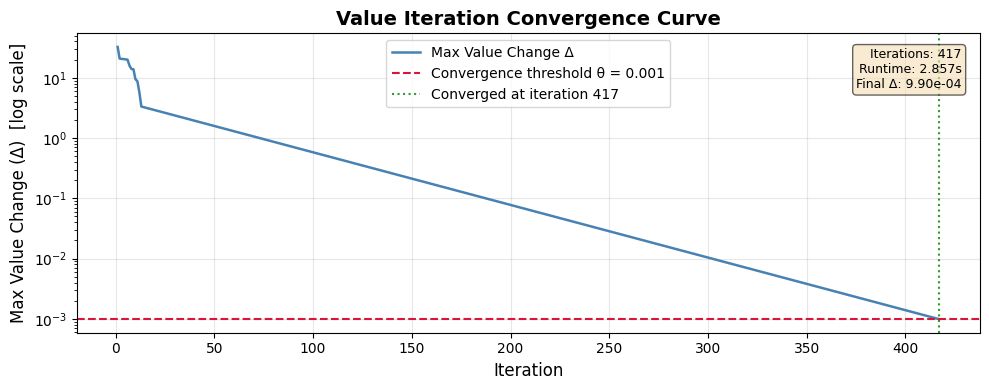

Convergence plot saved as 'vi_convergence.png'


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# RUN VALUE ITERATION
# ──────────────────────────────────────────────────────────────────────────────

V_star, pi_star, vi_iters, vi_elapsed, vi_final_delta, vi_deltas = value_iteration(
    all_states, non_terminal_states
)

# ── Results summary ────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("  VALUE ITERATION — CONVERGENCE RESULTS")
print("=" * 55)
print(f"  Convergence iterations : {vi_iters}")
print(f"  Total runtime          : {vi_elapsed:.4f} seconds")
print(f"  Final Δ (max change)   : {vi_final_delta:.2e}")
print(f"  Convergence threshold  : {THETA:.0e}")
print(f"  States updated (VI)    : {len(non_terminal_states):,}")
print(f"  Policy entries (π*)    : {len(pi_star):,}")
print("=" * 55)
print()

# ── Sample value outputs ───────────────────────────────────────────────────────
print("Sample V*(s) at battery=15, mask=0b000 (initial conditions):")
print()
positions_of_interest = [
    ((0, 0), 'S  — Start position'),
    ((2, 5), 'R0 — First rescue target'),
    ((4, 5), 'R1 — Second rescue target'),
    ((5, 4), 'R2 — Third rescue target'),
    ((3, 4), 'C0 — Charging station 1'),
    ((5, 2), 'C1 — Charging station 2'),
    ((1, 1), 'D  — Danger zone'),
    ((4, 4), 'D  — Danger zone'),
    ((2, 4), 'W  — Wind zone'),
    ((5, 0), 'F  — Bottom-left free cell'),
]
print(f"  {'Position':<10} {'Cell':<25} {'V*(bat=15,mask=0)':>18} {'π*(bat=15,mask=0)':>18}")
print("  " + "-" * 73)
for (r, c), label in positions_of_interest:
    if (r, c) not in BLOCKED_POSITIONS:
        s = (r, c, 15, 0)
        v = V_star.get(s, 0.0)
        a = pi_star.get(s)
        print(f"  ({r},{c}){'':<7} {label:<25} {v:>18.4f} {ACTION_NAMES.get(a, '—'):>18}")

# ── Convergence curve ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Plot delta curve on log scale to see convergence clearly
ax.semilogy(range(1, vi_iters + 1), vi_deltas,
            color='steelblue', linewidth=1.8, label='Max Value Change Δ')

# Draw convergence threshold line
ax.axhline(y=THETA, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Convergence threshold θ = {THETA}')

# Annotate the convergence point
ax.axvline(x=vi_iters, color='green', linestyle=':', linewidth=1.5, alpha=0.8,
           label=f'Converged at iteration {vi_iters}')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Max Value Change (Δ)  [log scale]', fontsize=12)
ax.set_title('Value Iteration Convergence Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Add text box with summary stats
stats_text = (f'Iterations: {vi_iters}\n'
              f'Runtime: {vi_elapsed:.3f}s\n'
              f'Final Δ: {vi_final_delta:.2e}')
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('vi_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Convergence plot saved as 'vi_convergence.png'")

---
## Section 3 — Policy Visualisation

The optimal policy $\pi^*(s)$ is visualised by fixing a *slice* of the state space (battery level and rescue mask) and plotting the best action for every valid grid position.

**Colour scheme:**
- Background shading: V*(s) heatmap (red = low value, green = high value)
- Cell symbol in top-left corner: actual cell type
- Arrow in centre: optimal action (↑↓←→●)
- Number at bottom: V*(s) value

**What to look for:**
- Arrows pointing **toward rescue targets** (positive reward)
- Arrows **avoiding danger zones** (D cells are red and low-value)
- Arrows pointing **toward charging stations** when battery is low
- **Hover (●)** at charging stations when battery needs replenishing

Plotting policy: battery=15, mask=000 (initial state slice)
Saved: policy_bat15_mask000.png


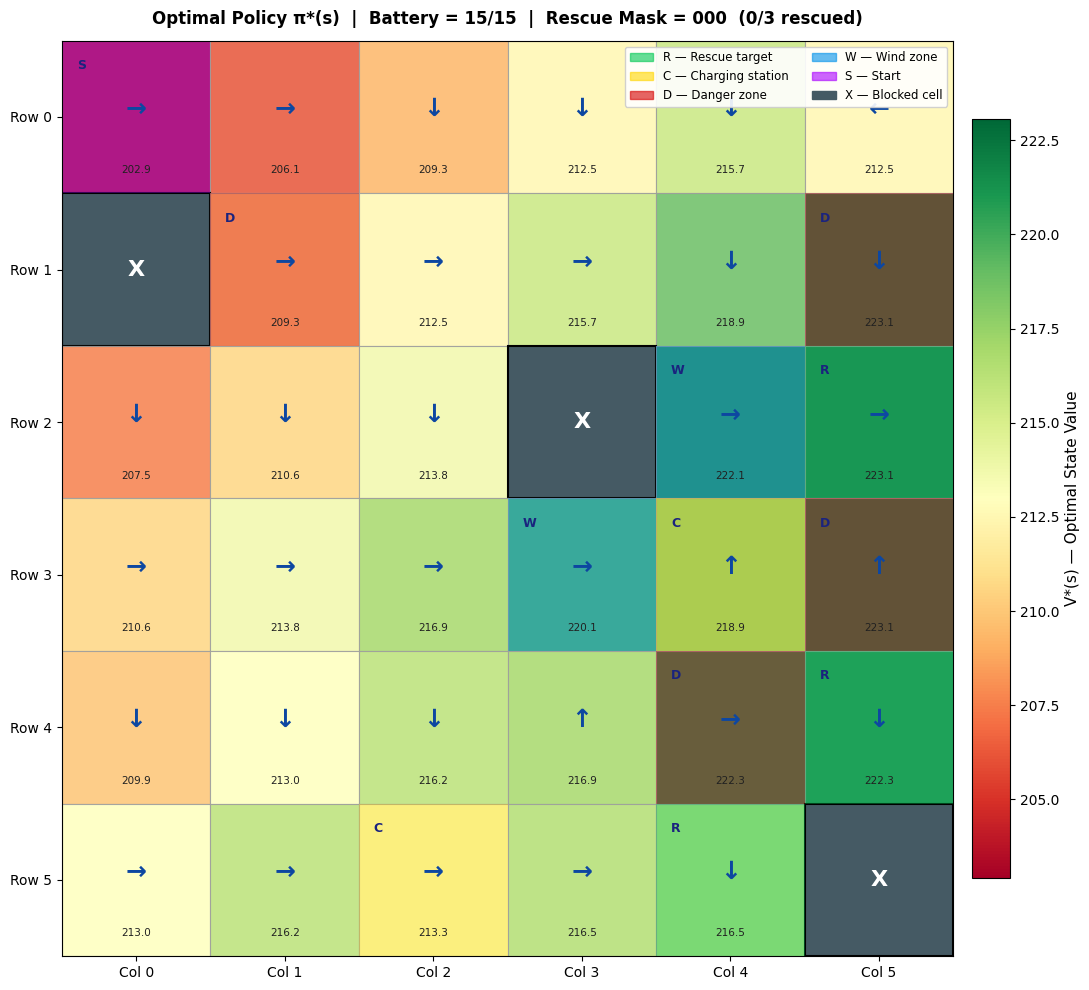

Plotting policy: battery=4, mask=000 (low battery — charging urgency)
Saved: policy_bat4_mask000.png


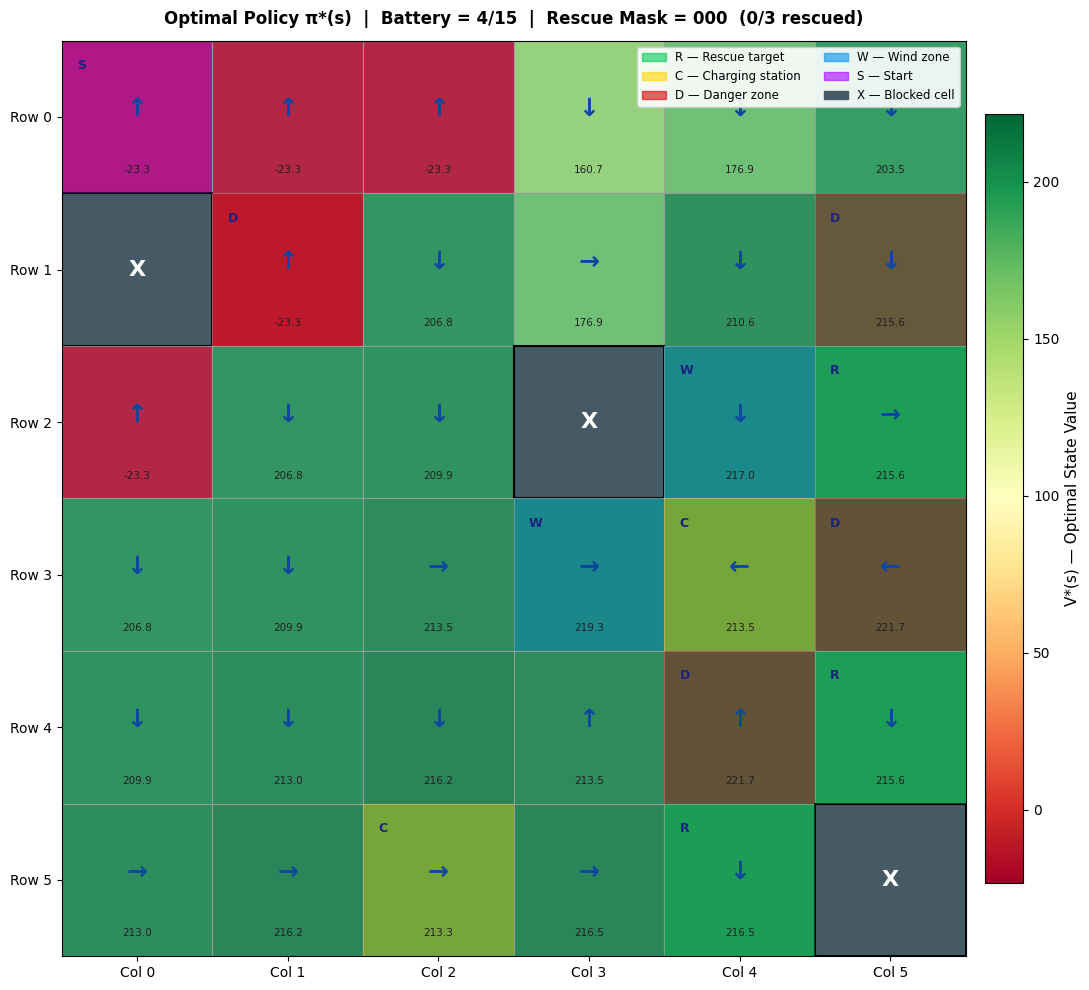

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# POLICY VISUALISATION — ARROW GRID WITH VALUE HEATMAP
# ──────────────────────────────────────────────────────────────────────────────

def plot_policy_grid(pi_star, V_star, battery, mask, title=None, ax=None, save_name=None):
    """
    Visualise the optimal policy π*(s) as a grid of directional arrows.

    Each cell is coloured by its V*(s) value (red=low → green=high). The
    optimal action for each position is overlaid as an arrow (↑↓←→) or
    hover symbol (●). Blocked cells are shown in dark grey with an 'X'.

    Args:
        pi_star   (dict) : Optimal policy {state → action}
        V_star    (dict) : Optimal value function {state → V*(s)}
        battery   (int)  : Battery level to fix for this slice
        mask      (int)  : Rescue bitmask to fix for this slice
        title     (str)  : Plot title (auto-generated if None)
        ax               : Matplotlib axis (creates new figure if None)
        save_name (str)  : Filename to save (if not None)
    """
    # Build value grid and collect per-cell data
    val_grid  = np.full((NROWS, NCOLS), np.nan)
    act_grid  = {}    # (r,c) → arrow symbol
    cell_type = {}    # (r,c) → cell symbol for labelling

    for r in range(NROWS):
        for c in range(NCOLS):
            if (r, c) in BLOCKED_POSITIONS:
                continue
            s               = (r, c, battery, mask)
            val_grid[r][c]  = V_star.get(s, 0.0)
            act_grid[(r,c)] = ACTION_ARROWS.get(pi_star.get(s), '?')
            cell_type[(r,c)] = GRID_BASE[r][c]

    # Compute colormap range from non-NaN values
    valid_vals = val_grid[~np.isnan(val_grid)]
    vmin = valid_vals.min() if len(valid_vals) > 0 else 0
    vmax = valid_vals.max() if len(valid_vals) > 0 else 1
    cmap = plt.cm.RdYlGn   # Red (low value) → Yellow → Green (high value)

    created_own_fig = ax is None
    if created_own_fig:
        fig, ax = plt.subplots(figsize=(11, 10))

    # Cell colour palettes for special cell types
    SPECIAL_ALPHA = 0.35   # Blend factor for special cell background tint
    CELL_TINTS = {
        'R': '#00C853',   # Green tint for rescue targets
        'C': '#FFD600',   # Yellow tint for charging stations
        'D': '#D50000',   # Red tint for danger zones
        'W': '#0091EA',   # Blue tint for wind zones
        'S': '#AA00FF',   # Purple tint for start
    }

    for r in range(NROWS):
        for c in range(NCOLS):
            x = c           # x-axis = column
            y = NROWS - 1 - r  # y-axis inverted so row 0 is at top

            if (r, c) in BLOCKED_POSITIONS:
                # Blocked cell: solid dark grey
                rect = plt.Rectangle((x, y), 1, 1, facecolor='#455A64',
                                     edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                ax.text(x + 0.5, y + 0.5, 'X', ha='center', va='center',
                        fontsize=16, color='white', fontweight='bold')
                continue

            # Background: value heatmap colour
            val = val_grid[r][c]
            if not np.isnan(val) and vmax > vmin:
                norm_v = (val - vmin) / (vmax - vmin)
                bg_color = cmap(norm_v)
            else:
                bg_color = '#EEEEEE'

            rect = plt.Rectangle((x, y), 1, 1, facecolor=bg_color,
                                 edgecolor='#9E9E9E', linewidth=0.8, alpha=0.85)
            ax.add_patch(rect)

            # Cell type symbol (top-left corner)
            sym = GRID_BASE[r][c]
            sym_display = effective_cell(r, c, mask)
            if sym in CELL_TINTS:
                # Tinted overlay for special cells
                tint = plt.Rectangle((x, y), 1, 1, facecolor=CELL_TINTS[sym],
                                     alpha=SPECIAL_ALPHA, zorder=2)
                ax.add_patch(tint)
                ax.text(x + 0.1, y + 0.88, sym, ha='left', va='top',
                        fontsize=9, color='#1A237E', fontweight='bold', zorder=3)

            # V*(s) value at bottom of cell
            ax.text(x + 0.5, y + 0.15, f'{val:.1f}',
                    ha='center', va='center', fontsize=7.5,
                    color='#212121', zorder=3)

            # Optimal action arrow at centre of cell
            arrow_sym = act_grid.get((r, c), '?')
            arrow_fs  = 18 if arrow_sym in ('↑', '↓', '←', '→') else 13
            ax.text(x + 0.5, y + 0.55, arrow_sym,
                    ha='center', va='center', fontsize=arrow_fs,
                    color='#0D47A1', fontweight='bold', zorder=3)

    # Colour bar for V*(s)
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label('V*(s) — Optimal State Value', fontsize=11)

    # Axis setup
    ax.set_xlim(0, NCOLS)
    ax.set_ylim(0, NROWS)
    ax.set_xticks([i + 0.5 for i in range(NCOLS)])
    ax.set_xticklabels([f'Col {i}' for i in range(NCOLS)], fontsize=10)
    ax.set_yticks([i + 0.5 for i in range(NROWS)])
    ax.set_yticklabels([f'Row {NROWS-1-i}' for i in range(NROWS)], fontsize=10)

    # Legend patches
    legend_handles = [
        mpatches.Patch(color='#00C853', alpha=0.6, label='R — Rescue target'),
        mpatches.Patch(color='#FFD600', alpha=0.6, label='C — Charging station'),
        mpatches.Patch(color='#D50000', alpha=0.6, label='D — Danger zone'),
        mpatches.Patch(color='#0091EA', alpha=0.6, label='W — Wind zone'),
        mpatches.Patch(color='#AA00FF', alpha=0.6, label='S — Start'),
        mpatches.Patch(color='#455A64',             label='X — Blocked cell'),
    ]
    ax.legend(handles=legend_handles, loc='upper right',
              fontsize=8.5, framealpha=0.9, ncol=2)

    mask_str = bin(mask)[2:].zfill(NUM_RESCUES)
    if title is None:
        rescues_done = bin(mask).count('1')
        title = (f'Optimal Policy π*(s)  |  Battery = {battery}/{MAX_BATTERY}  |  '
                 f'Rescue Mask = {mask_str}  ({rescues_done}/{NUM_RESCUES} rescued)')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    if created_own_fig:
        plt.tight_layout()
        if save_name:
            plt.savefig(save_name, dpi=150, bbox_inches='tight')
            print(f"Saved: {save_name}")
        plt.show()


# ── Plot 1: Full battery, no rescues — initial decision slice ─────────────────
print("Plotting policy: battery=15, mask=000 (initial state slice)")
plot_policy_grid(pi_star, V_star, battery=15, mask=0b000,
                 save_name='policy_bat15_mask000.png')

# ── Plot 2: Low battery — shows charging-seeking behaviour ───────────────────
print("Plotting policy: battery=4, mask=000 (low battery — charging urgency)")
plot_policy_grid(pi_star, V_star, battery=4, mask=0b000,
                 save_name='policy_bat4_mask000.png')

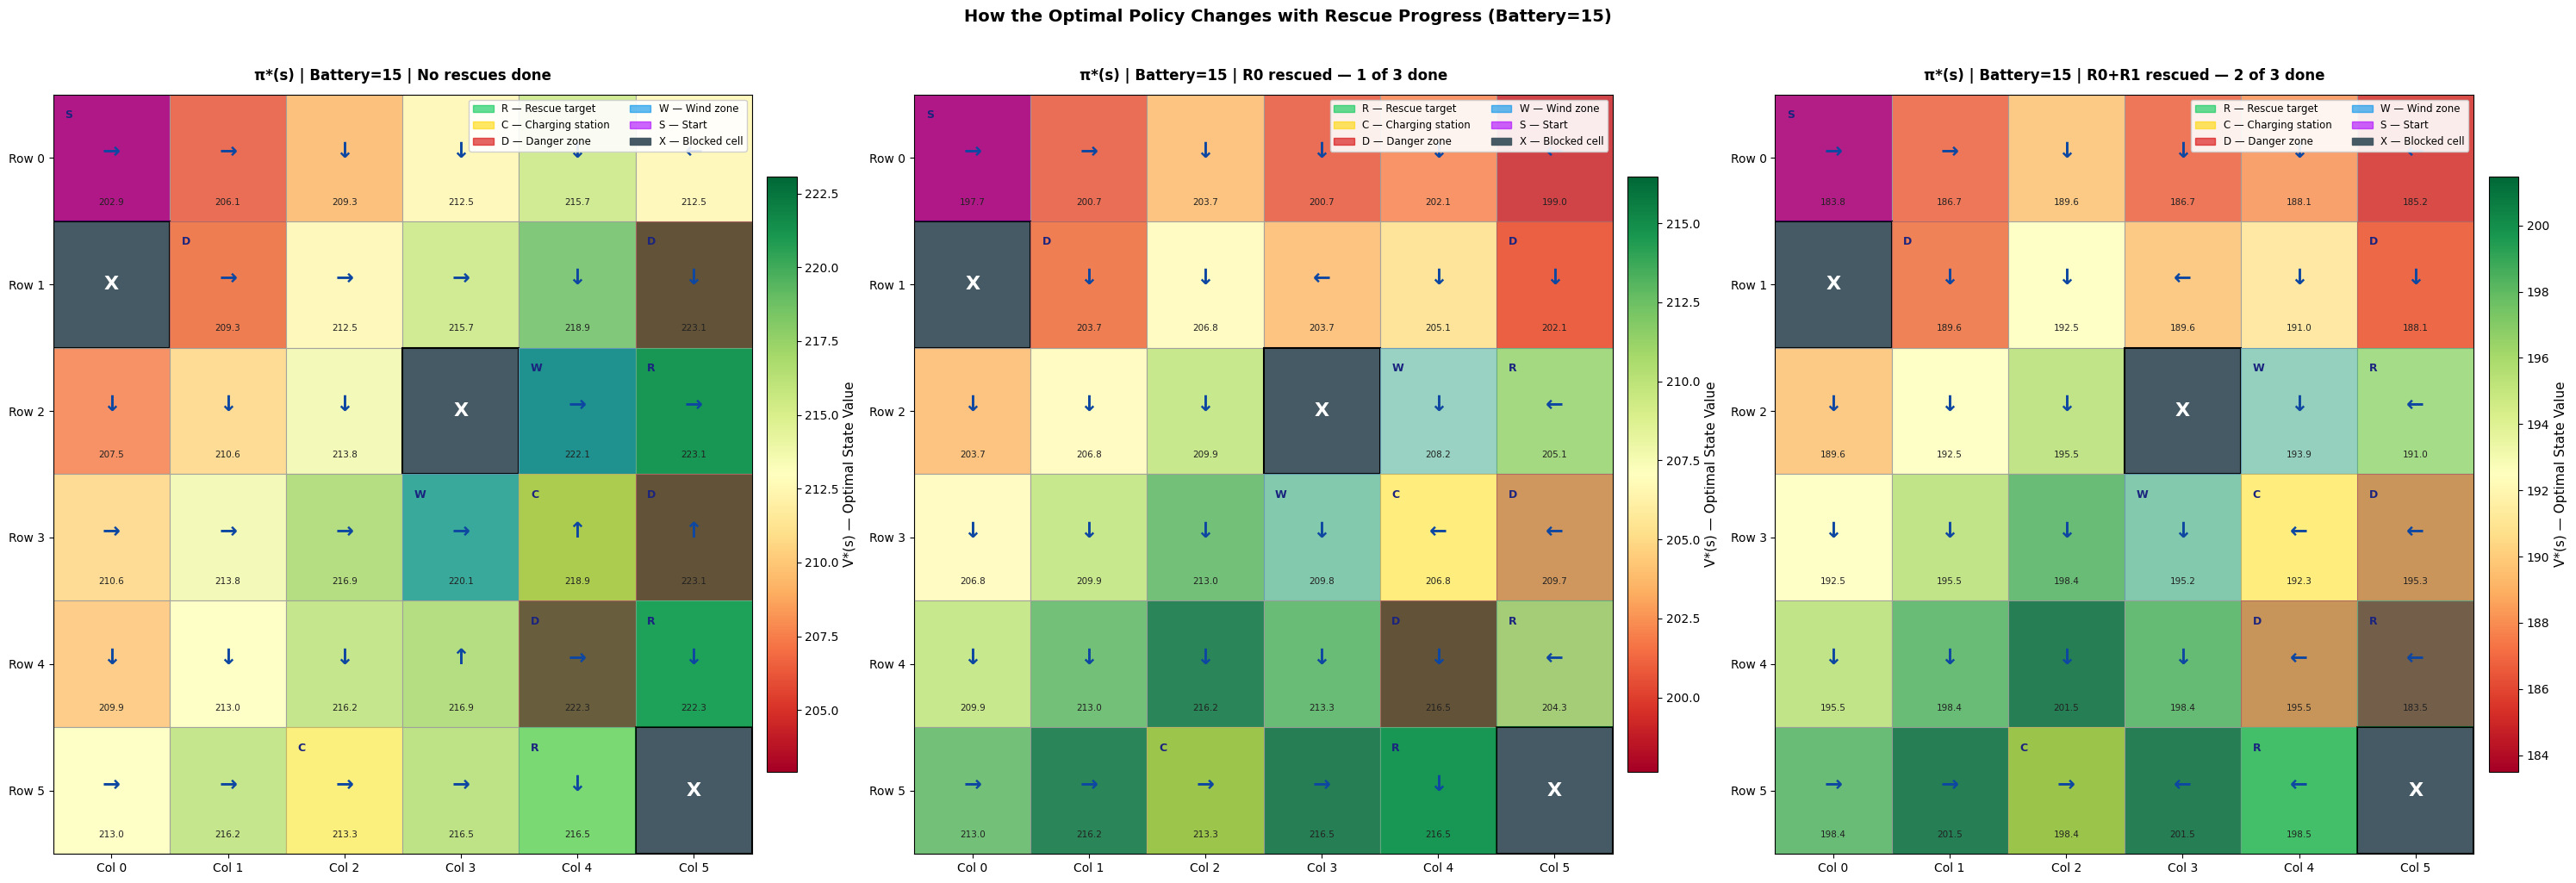

Saved: policy_rescue_progression.png


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# SIDE-BY-SIDE POLICY COMPARISON: Three rescue-progress slices
# Shows how the policy adapts as rescue targets are collected
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

slices = [
    (0b000, 'No rescues done'),
    (0b001, 'R0 rescued — 1 of 3 done'),
    (0b011, 'R0+R1 rescued — 2 of 3 done'),
]

for ax, (mask, subtitle) in zip(axes, slices):
    plot_policy_grid(pi_star, V_star, battery=15, mask=mask,
                     title=f'π*(s) | Battery=15 | {subtitle}', ax=ax)

plt.suptitle('How the Optimal Policy Changes with Rescue Progress (Battery=15)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('policy_rescue_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: policy_rescue_progression.png")

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# RESCUE TRAJECTORY SIMULATION
# Simulate one full episode following π*(s) and visualise the drone's path
# ──────────────────────────────────────────────────────────────────────────────

def simulate_episode(env, pi_star, episode_seed=42):
    """
    Simulate one complete episode following the optimal policy π*(s).

    At each step the drone selects its action greedily from π*(s). Wind
    disturbances are applied stochastically by the environment. A fixed
    episode_seed ensures reproducible trajectories for analysis.

    Args:
        env          (DroneRescueEnv) : Environment instance
        pi_star      (dict)           : Optimal policy {state → action}
        episode_seed (int)            : Seed for wind randomness in this episode

    Returns:
        trajectory   (list)  : List of per-step dicts with pos/battery/action/reward
        total_reward (float) : Accumulated undiscounted reward for the episode
    """
    random.seed(episode_seed)  # Fix wind randomness for reproducible trajectory
    state = env.reset()

    # Record initial state as step 0
    trajectory = [{
        'step':    0,
        'pos':     (state[0], state[1]),
        'battery': state[2],
        'mask':    state[3],
        'action':  None,
        'reward':  0.0,
        'done':    False,
        'info':    {}
    }]
    total_reward = 0.0

    for _ in range(MAX_STEPS):
        # Select optimal action; fall back to HOVER if state not in policy
        action = pi_star.get(state, HOVER)

        next_state, reward, done, info = env.step(action)
        total_reward += reward

        trajectory.append({
            'step':    len(trajectory),
            'pos':     (next_state[0], next_state[1]),
            'battery': next_state[2],
            'mask':    next_state[3],
            'action':  action,
            'reward':  reward,
            'done':    done,
            'info':    info
        })
        state = next_state

        if done:
            break

    return trajectory, total_reward


# Run the simulation
env_sim    = DroneRescueEnv()
trajectory, total_reward = simulate_episode(env_sim, pi_star, episode_seed=42)

# Print episode summary
print("=" * 65)
print("  EPISODE TRAJECTORY (following π*)")
print("=" * 65)
print(f"  Steps taken    : {len(trajectory) - 1}")
print(f"  Total reward   : {total_reward:.1f}")
print(f"  Final battery  : {trajectory[-1]['battery']}/{MAX_BATTERY}")
print(f"  Rescue mask    : {bin(trajectory[-1]['mask'])[2:].zfill(NUM_RESCUES)}"
      f"  ({bin(trajectory[-1]['mask']).count('1')}/{NUM_RESCUES} rescued)")
print(f"  Termination    : {trajectory[-1]['info'].get('reason', 'ongoing')}")
print()

# Step-by-step log
print(f"  {'Step':>4}  {'Pos':>6}  {'Action':>6}  {'Bat':>3}  {'Mask':>4}  {'Reward':>7}  Event")
print("  " + "-" * 65)
for t in trajectory:
    act_name = ACTION_NAMES.get(t['action'], 'START') if t['action'] is not None else 'START'
    mask_str = bin(t['mask'])[2:].zfill(NUM_RESCUES)
    event = ''
    if 'rescued' in t['info']:
        event = f"RESCUED {t['info']['rescued']}"
    elif t['reward'] == R_CHARGE_ENTRY:
        event = 'CHARGED (full)'
    elif t['reward'] == R_DANGER:
        event = 'DANGER zone'
    elif t['info'].get('wind_redirected'):
        event = 'wind redirect'
    elif t['info'].get('reason'):
        event = t['info']['reason'].upper()
    print(f"  {t['step']:>4}  {str(t['pos']):>6}  {act_name:>6}  "
          f"{t['battery']:>3}  {mask_str:>4}  {t['reward']:>7.1f}  {event}")

  EPISODE TRAJECTORY (following π*)
  Steps taken    : 75
  Total reward   : 153.0
  Final battery  : 14/15
  Rescue mask    : 101  (2/3 rescued)
  Termination    : max_steps_exceeded

  Step     Pos  Action  Bat  Mask   Reward  Event
  -----------------------------------------------------------------
     0  (0, 0)   START   15   000      0.0  
     1  (0, 1)   RIGHT   14   000     -1.0  
     2  (0, 2)   RIGHT   13   000     -1.0  
     3  (1, 2)    DOWN   12   000     -1.0  
     4  (1, 3)   RIGHT   11   000     -1.0  
     5  (1, 4)   RIGHT   10   000     -1.0  
     6  (2, 4)    DOWN    9   000     -1.0  
     7  (2, 5)   RIGHT    8   001     20.0  RESCUED (2, 5)
     8  (2, 4)    LEFT    7   001     -1.0  
     9  (2, 4)    DOWN    6   001     -1.0  wind redirect
    10  (3, 4)    DOWN   15   001      5.0  CHARGED (full)
    11  (3, 3)    LEFT   14   001     -1.0  
    12  (4, 3)    DOWN   13   001     -1.0  
    13  (5, 3)    DOWN   12   001     -1.0  
    14  (5, 4)   RIGHT   1

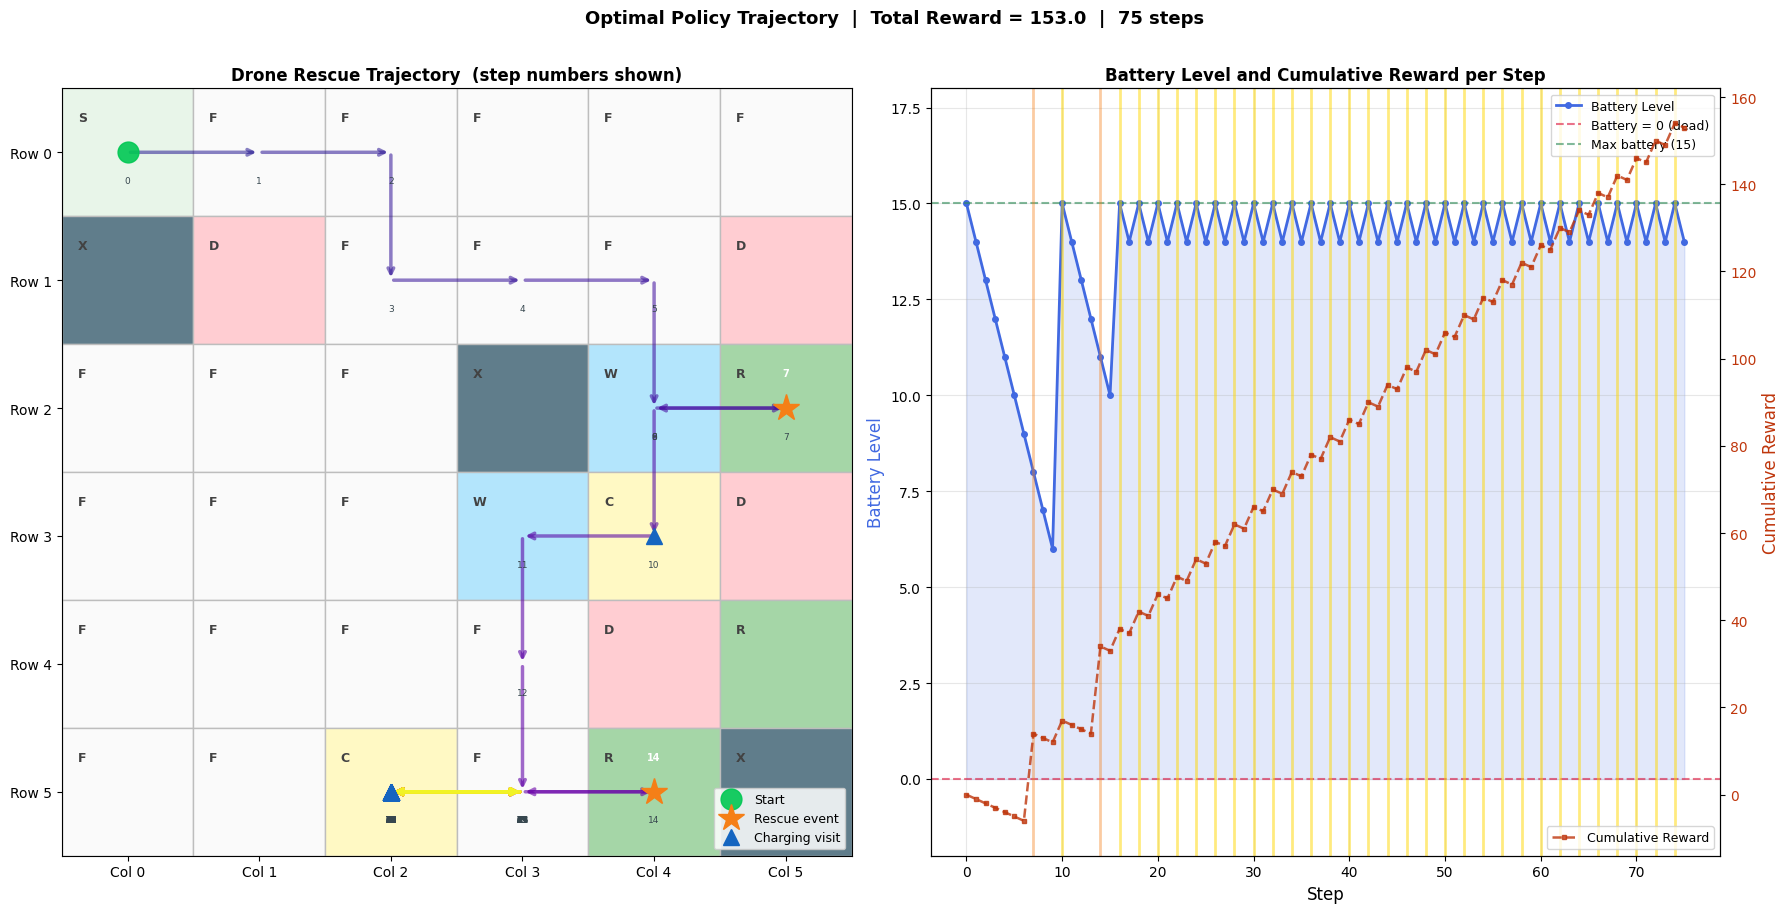

Saved: trajectory.png


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# TRAJECTORY VISUALISATION: Grid path + battery/reward over time
# ──────────────────────────────────────────────────────────────────────────────

def plot_trajectory(trajectory, total_reward):
    """
    Plot the drone's rescue trajectory on the grid alongside a battery/reward chart.

    Left panel: Grid with colour-coded cells and the drone path drawn as
    arrows that darken over time (light=early, dark=late). Rescue events
    are marked with green stars; charging visits with yellow triangles.

    Right panel: Battery level over time (blue) and cumulative reward (red).
    Rescue events and charging visits are marked with vertical lines.

    Args:
        trajectory   (list)  : Output from simulate_episode()
        total_reward (float) : Episode total reward (for title)
    """
    fig, (ax_grid, ax_bat) = plt.subplots(1, 2, figsize=(18, 9))

    # ── Left panel: Grid with trajectory ─────────────────────────────────────
    CELL_COLORS = {
        'S': '#E8F5E9', 'F': '#FAFAFA', 'R': '#A5D6A7',
        'C': '#FFF9C4', 'D': '#FFCDD2', 'W': '#B3E5FC', 'X': '#607D8B'
    }

    # Draw all grid cells
    for r in range(NROWS):
        for c in range(NCOLS):
            sym   = GRID_BASE[r][c]
            color = CELL_COLORS.get(sym, '#FAFAFA')
            rect  = plt.Rectangle((c, NROWS - 1 - r), 1, 1,
                                  facecolor=color, edgecolor='#BDBDBD', lw=1.0)
            ax_grid.add_patch(rect)
            # Cell label
            ax_grid.text(c + 0.12, NROWS - 0.18 - r, sym, ha='left', va='top',
                         fontsize=9, color='#424242', fontweight='bold')

    # Draw path arrows with temporal gradient (lighter=earlier, darker=later)
    positions = [t['pos'] for t in trajectory]
    n_steps   = len(positions)
    path_cmap = plt.cm.plasma

    for i in range(1, n_steps):
        r1, c1 = positions[i - 1]
        r2, c2 = positions[i]
        color  = path_cmap(i / n_steps)   # Colour fades from purple to yellow
        alpha  = 0.5 + 0.5 * (i / n_steps)
        ax_grid.annotate('',
            xy=(c2 + 0.5, NROWS - 0.5 - r2),
            xytext=(c1 + 0.5, NROWS - 0.5 - r1),
            arrowprops=dict(arrowstyle='->', color=color, lw=2.5, alpha=alpha))

    # Mark start position with a large green circle
    r0, c0 = positions[0]
    ax_grid.plot(c0 + 0.5, NROWS - 0.5 - r0, 'o', color='#00C853',
                 markersize=15, zorder=6, label='Start', alpha=0.9)

    # Mark special events on the grid
    rescue_label_added  = False
    charge_label_added  = False
    for t in trajectory[1:]:
        r, c = t['pos']
        if 'rescued' in t['info']:
            lbl = 'Rescue event' if not rescue_label_added else None
            ax_grid.plot(c + 0.5, NROWS - 0.5 - r, '*',
                         color='#F57F17', markersize=20, zorder=7, label=lbl)
            ax_grid.text(c + 0.5, NROWS - 0.25 - r, str(t['step']),
                         ha='center', fontsize=7, color='white', fontweight='bold', zorder=8)
            rescue_label_added = True
        if t['reward'] == R_CHARGE_ENTRY:
            lbl = 'Charging visit' if not charge_label_added else None
            ax_grid.plot(c + 0.5, NROWS - 0.5 - r, '^',
                         color='#1565C0', markersize=12, zorder=7, label=lbl)
            charge_label_added = True

    # Overlay step numbers at each visited position
    visited_counts = {}
    for t in trajectory:
        r, c = t['pos']
        visited_counts[(r, c)] = visited_counts.get((r, c), 0) + 1

    for t in trajectory:
        r, c = t['pos']
        ax_grid.text(c + 0.5, NROWS - 0.72 - r, str(t['step']),
                     ha='center', va='center', fontsize=6.5, color='#37474F')

    ax_grid.set_xlim(0, NCOLS)
    ax_grid.set_ylim(0, NROWS)
    ax_grid.set_xticks([i + 0.5 for i in range(NCOLS)])
    ax_grid.set_xticklabels([f'Col {i}' for i in range(NCOLS)], fontsize=10)
    ax_grid.set_yticks([i + 0.5 for i in range(NROWS)])
    ax_grid.set_yticklabels([f'Row {NROWS-1-i}' for i in range(NROWS)], fontsize=10)
    ax_grid.set_title('Drone Rescue Trajectory  (step numbers shown)',
                      fontsize=12, fontweight='bold')
    ax_grid.legend(loc='lower right', fontsize=9, framealpha=0.85)

    # ── Right panel: Battery and cumulative reward over time ──────────────────
    steps     = [t['step'] for t in trajectory]
    batteries = [t['battery'] for t in trajectory]
    rewards   = [t['reward'] for t in trajectory[1:]]
    cum_rew   = list(np.cumsum([0.0] + rewards))

    ax_bat.fill_between(steps, batteries, alpha=0.15, color='royalblue')
    ax_bat.plot(steps, batteries, 'o-', color='royalblue', linewidth=2,
                markersize=4, label='Battery Level')
    ax_bat.axhline(y=0,           color='crimson',  linestyle='--', alpha=0.6,
                   linewidth=1.5, label='Battery = 0 (dead)')
    ax_bat.axhline(y=MAX_BATTERY, color='seagreen', linestyle='--', alpha=0.6,
                   linewidth=1.5, label=f'Max battery ({MAX_BATTERY})')

    # Vertical markers for key events
    for t in trajectory[1:]:
        if 'rescued' in t['info']:
            ax_bat.axvline(x=t['step'], color='#F57F17', alpha=0.4, linewidth=2)
        if t['reward'] == R_CHARGE_ENTRY:
            ax_bat.axvline(x=t['step'], color='gold', alpha=0.5, linewidth=2)

    ax_bat.set_xlabel('Step', fontsize=12)
    ax_bat.set_ylabel('Battery Level', fontsize=12, color='royalblue')
    ax_bat.set_ylim(-2, MAX_BATTERY + 3)
    ax_bat.legend(loc='upper right', fontsize=9)
    ax_bat.grid(True, alpha=0.3)

    # Overlay cumulative reward on secondary y-axis
    ax2 = ax_bat.twinx()
    ax2.plot(steps, cum_rew, 's--', color='#BF360C', linewidth=1.8,
             markersize=3, alpha=0.8, label='Cumulative Reward')
    ax2.set_ylabel('Cumulative Reward', fontsize=12, color='#BF360C')
    ax2.tick_params(axis='y', labelcolor='#BF360C')
    ax2.legend(loc='lower right', fontsize=9)

    ax_bat.set_title('Battery Level and Cumulative Reward per Step',
                     fontsize=12, fontweight='bold')

    plt.suptitle(f'Optimal Policy Trajectory  |  Total Reward = {total_reward:.1f}  |  '
                 f'{len(trajectory)-1} steps', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: trajectory.png")


plot_trajectory(trajectory, total_reward)

---
## Section 4 — State-Value Analysis

### 4.1 Methodology

A *slice* of the 4-dimensional value function $V^*(r, c, b, m)$ is obtained by **fixing two dimensions** (battery level $b$ and rescue mask $m$) and varying the drone position $(r, c)$ across the 6×6 grid. This yields a **2D heatmap** of state values.

**Chosen slices for analysis:**
1. `battery=15, mask=000` — Fresh start: full battery, no rescues
2. `battery=8, mask=000` — Mid-battery: same rescue state, less time
3. `battery=4, mask=000` — Critical battery: urgency to charge
4. `battery=15, mask=001` — After rescuing R0: drone knows R1/R2 remain
5. `battery=15, mask=011` — After rescuing R0+R1: one target left
6. `battery=15, mask=110` — After rescuing R1+R2: only R0 remains

**Expected patterns:**
- High V* near unrescued rescue targets (they offer +20 reward)
- Low V* near danger zones (risk of −10 penalty)
- V* decreases as battery decreases (fewer moves = less future reward)
- V* near charging stations is higher at low battery (urgency to charge)
- Blocked cells have no value (drone cannot be there)

Primary Heatmap: battery=15, mask=000
Saved: heatmap_bat15_mask000.png


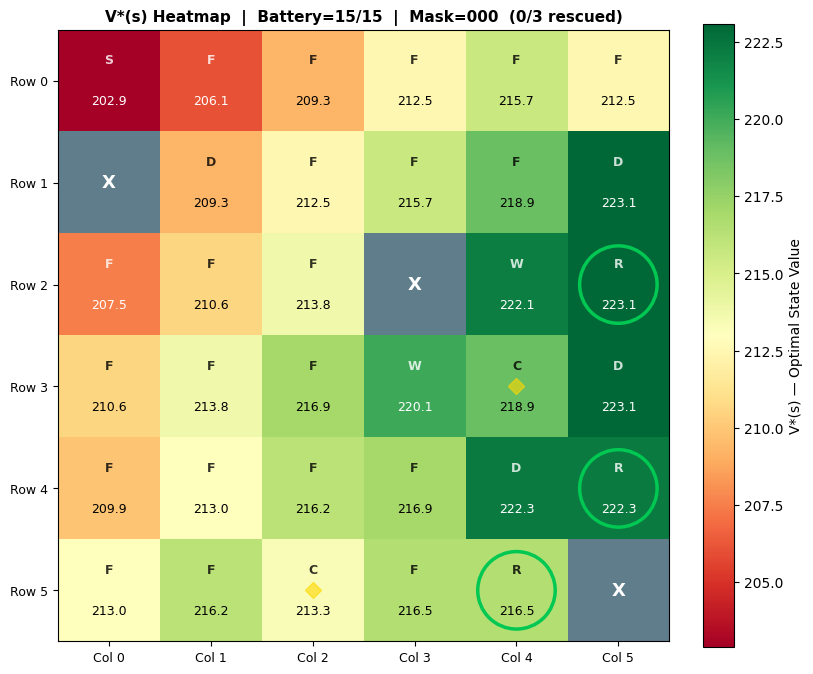

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# STATE-VALUE HEATMAP — Single slice: battery=15, mask=000
# ──────────────────────────────────────────────────────────────────────────────

def plot_value_heatmap(V_star, battery, mask, title=None, ax=None, save_name=None):
    """
    Plot a heatmap of V*(s) across all grid positions for fixed battery and mask.

    Produces a 6×6 heatmap where colour indicates the state value. Each cell
    shows the V* value and the original cell type symbol. Blocked cells appear
    in dark grey. Unrescued rescue targets are highlighted with a green circle;
    already-rescued targets have a grey circle.

    Args:
        V_star    (dict) : Optimal value function {state → V*(s)}
        battery   (int)  : Fixed battery level for this slice
        mask      (int)  : Fixed rescue bitmask for this slice
        title     (str)  : Plot title (auto-generated if None)
        ax               : Matplotlib axis (creates new fig if None)
        save_name (str)  : Filename to save (if not None)

    Returns:
        im: The imshow AxesImage object (for external colourbar if needed)
    """
    # Build 6×6 value matrix
    val_grid = np.full((NROWS, NCOLS), np.nan)
    for r in range(NROWS):
        for c in range(NCOLS):
            if (r, c) not in BLOCKED_POSITIONS:
                s = (r, c, battery, mask)
                val_grid[r][c] = V_star.get(s, 0.0)

    created_own_fig = ax is None
    if created_own_fig:
        fig, ax = plt.subplots(figsize=(8, 7))

    # Masked array: NaN (blocked) cells shown in grey
    masked_grid = np.ma.masked_where(np.isnan(val_grid), val_grid)
    cmap = plt.cm.RdYlGn.copy()
    cmap.set_bad(color='#607D8B')   # Blocked cells: steel grey

    vmin = float(np.nanmin(val_grid)) if not np.all(np.isnan(val_grid)) else 0
    vmax = float(np.nanmax(val_grid)) if not np.all(np.isnan(val_grid)) else 1

    im = ax.imshow(masked_grid, cmap=cmap, vmin=vmin, vmax=vmax,
                   aspect='equal', interpolation='nearest')

    # Annotate cells with value and cell type
    for r in range(NROWS):
        for c in range(NCOLS):
            if (r, c) in BLOCKED_POSITIONS:
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=13, color='white', fontweight='bold')
            else:
                sym = GRID_BASE[r][c]
                val = val_grid[r][c]
                # Choose text colour based on background brightness
                if not np.isnan(val) and vmax > vmin:
                    norm_v   = (val - vmin) / (vmax - vmin)
                    txt_color = 'white' if norm_v < 0.3 or norm_v > 0.85 else 'black'
                else:
                    txt_color = 'black'
                ax.text(c, r - 0.2, sym, ha='center', va='center',
                        fontsize=9, color=txt_color, fontweight='bold', alpha=0.8)
                ax.text(c, r + 0.2, f'{val:.1f}', ha='center', va='center',
                        fontsize=9, color=txt_color)

    # Highlight rescue targets: green circle=unrescued, grey circle=rescued
    for i, (rr, cc) in enumerate(RESCUE_POSITIONS):
        if mask & (1 << i):   # Rescued
            ax.add_patch(plt.Circle((cc, rr), 0.38, fill=False,
                                    edgecolor='grey', linewidth=2, linestyle='--'))
        else:                  # Unrescued
            ax.add_patch(plt.Circle((cc, rr), 0.38, fill=False,
                                    edgecolor='#00C853', linewidth=2.5))

    # Highlight charging stations with a diamond marker
    for (rr, cc) in CHARGE_POSITIONS:
        ax.plot(cc, rr, 'D', color='gold', markersize=8, alpha=0.6, zorder=5)

    ax.set_xticks(range(NCOLS))
    ax.set_xticklabels([f'Col {i}' for i in range(NCOLS)], fontsize=9)
    ax.set_yticks(range(NROWS))
    ax.set_yticklabels([f'Row {i}' for i in range(NROWS)], fontsize=9)

    mask_str = bin(mask)[2:].zfill(NUM_RESCUES)
    rescues  = bin(mask).count('1')
    if title is None:
        title = (f'V*(s) Heatmap  |  Battery={battery}/{MAX_BATTERY}  |  '
                 f'Mask={mask_str}  ({rescues}/{NUM_RESCUES} rescued)')
    ax.set_title(title, fontsize=11, fontweight='bold')

    if created_own_fig:
        plt.colorbar(im, ax=ax, label='V*(s) — Optimal State Value', fraction=0.046)
        plt.tight_layout()
        if save_name:
            plt.savefig(save_name, dpi=150, bbox_inches='tight')
            print(f"Saved: {save_name}")
        plt.show()

    return im


# Primary heatmap: full battery, no rescues (initial game state)
print("Primary Heatmap: battery=15, mask=000")
plot_value_heatmap(V_star, battery=15, mask=0b000,
                   save_name='heatmap_bat15_mask000.png')

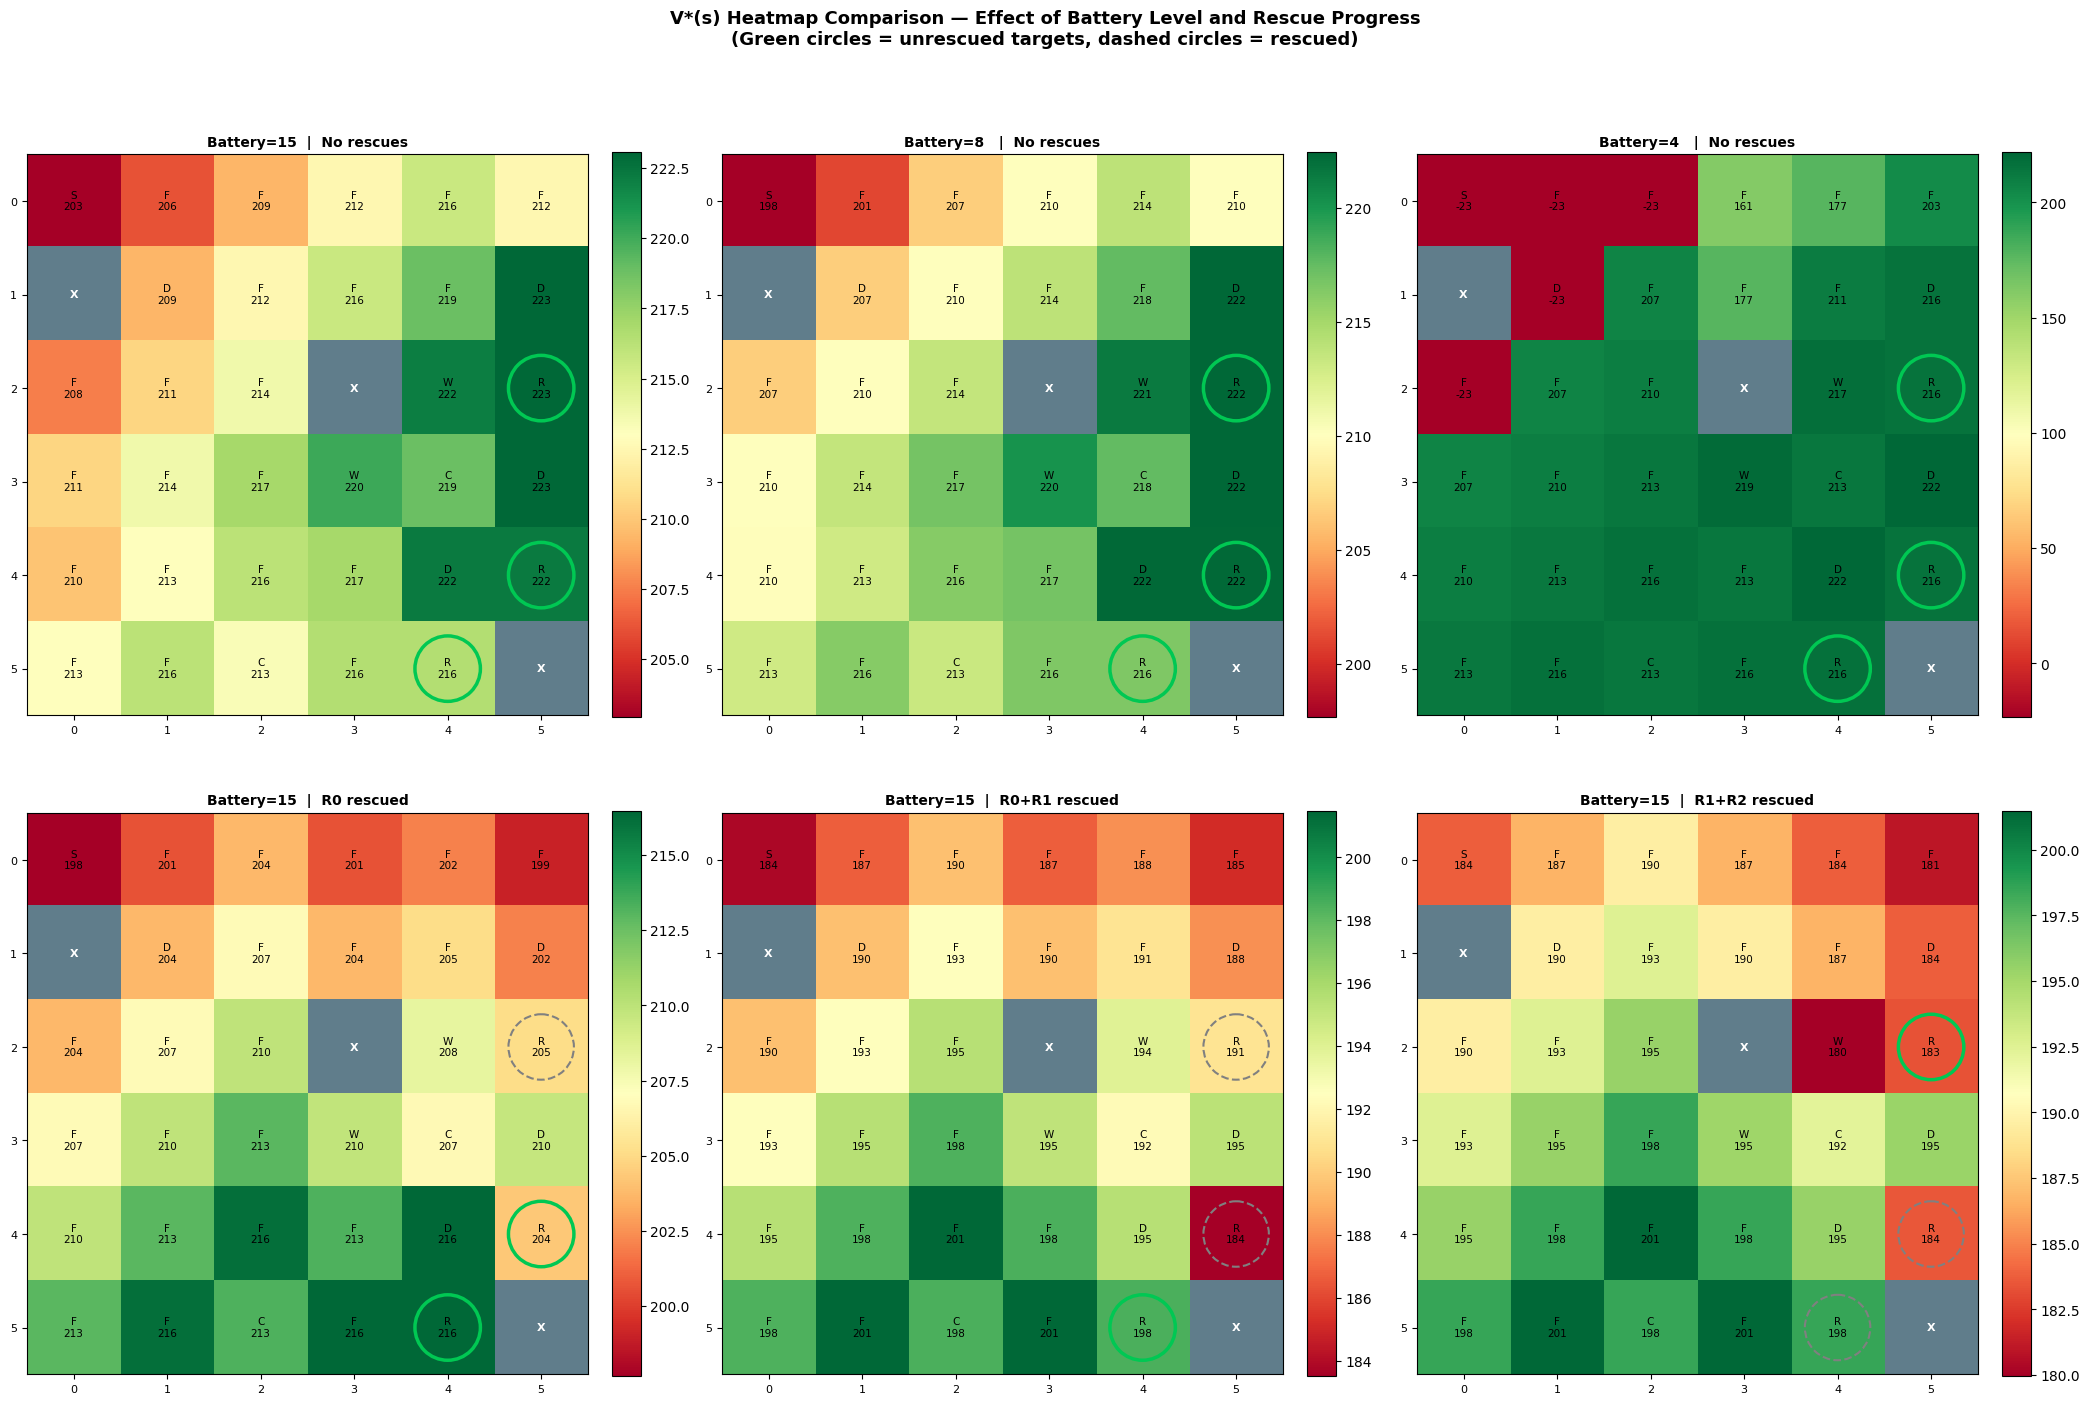

Saved: heatmap_comparison.png


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# COMPARATIVE HEATMAP ANALYSIS: 6 slices showing effect of battery and rescue state
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(21, 14))

# Six informative slices
slices = [
    (15, 0b000, 'Battery=15  |  No rescues'),
    (8,  0b000, 'Battery=8   |  No rescues'),
    (4,  0b000, 'Battery=4   |  No rescues'),
    (15, 0b001, 'Battery=15  |  R0 rescued'),
    (15, 0b011, 'Battery=15  |  R0+R1 rescued'),
    (15, 0b110, 'Battery=15  |  R1+R2 rescued'),
]

ims = []
for ax, (bat, mask, subtitle) in zip(axes.flat, slices):
    # Build value grid for this slice
    val_grid = np.full((NROWS, NCOLS), np.nan)
    for r in range(NROWS):
        for c in range(NCOLS):
            if (r, c) not in BLOCKED_POSITIONS:
                s = (r, c, bat, mask)
                val_grid[r][c] = V_star.get(s, 0.0)

    masked_grid = np.ma.masked_where(np.isnan(val_grid), val_grid)
    cmap_copy = plt.cm.RdYlGn.copy()
    cmap_copy.set_bad(color='#607D8B')
    vmin = float(np.nanmin(val_grid)) if not np.all(np.isnan(val_grid)) else 0
    vmax = float(np.nanmax(val_grid)) if not np.all(np.isnan(val_grid)) else 1

    im = ax.imshow(masked_grid, cmap=cmap_copy, vmin=vmin, vmax=vmax,
                   aspect='equal', interpolation='nearest')
    ims.append(im)

    # Annotate cells
    for r in range(NROWS):
        for c in range(NCOLS):
            if (r, c) in BLOCKED_POSITIONS:
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
            else:
                sym = GRID_BASE[r][c]
                val = val_grid[r][c]
                ax.text(c, r, f'{sym}\n{val:.0f}',
                        ha='center', va='center', fontsize=7.5, color='black')

    # Circle unrescued targets
    for i, (rr, cc) in enumerate(RESCUE_POSITIONS):
        color = 'grey' if (mask & (1 << i)) else '#00C853'
        lw    = 1.5   if (mask & (1 << i)) else 2.5
        ls    = '--'  if (mask & (1 << i)) else '-'
        ax.add_patch(plt.Circle((cc, rr), 0.35, fill=False,
                                edgecolor=color, linewidth=lw, linestyle=ls))

    ax.set_xticks(range(NCOLS))
    ax.set_xticklabels([str(i) for i in range(NCOLS)], fontsize=8)
    ax.set_yticks(range(NROWS))
    ax.set_yticklabels([str(i) for i in range(NROWS)], fontsize=8)
    ax.set_title(subtitle, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    'V*(s) Heatmap Comparison — Effect of Battery Level and Rescue Progress\n'
    '(Green circles = unrescued targets, dashed circles = rescued)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatmap_comparison.png")

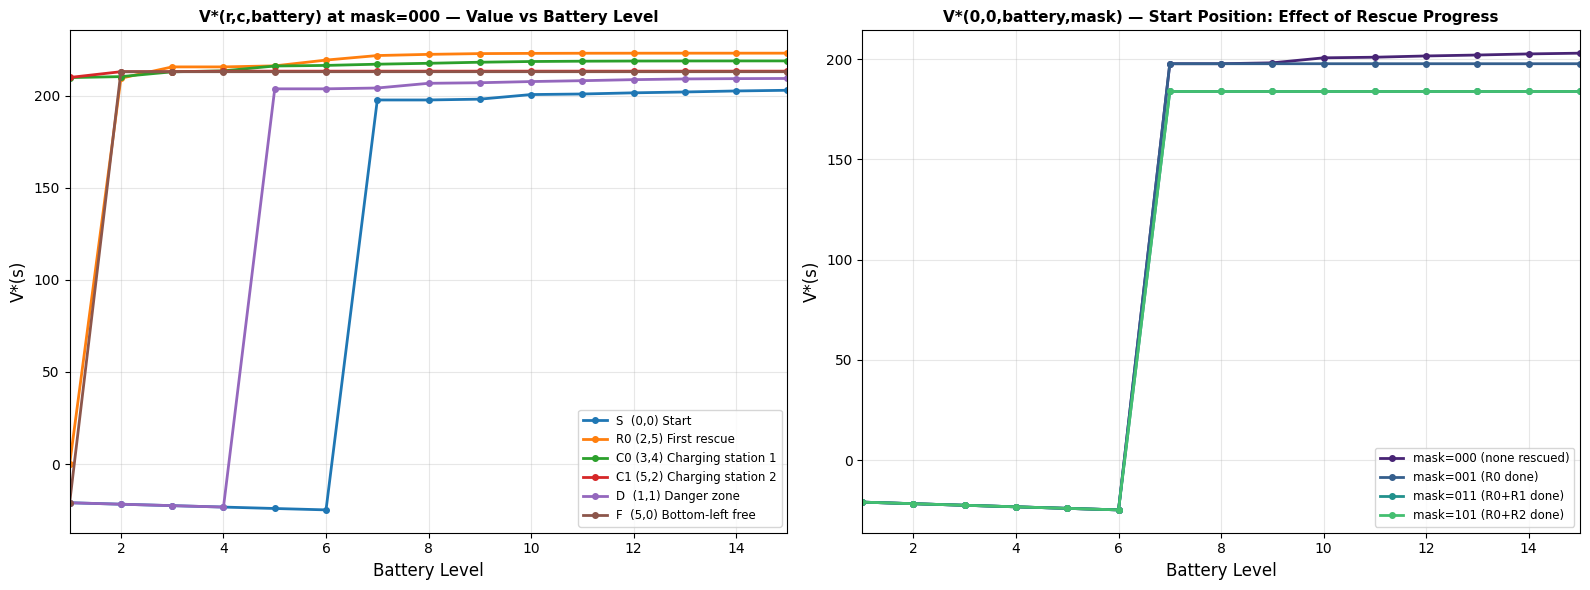

Saved: value_vs_battery.png


In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# BATTERY EFFECT ON VALUE FUNCTION: Line plots showing V*(r,c) vs battery
# for key positions — shows how urgency to charge changes with battery level
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

battery_range = list(range(1, MAX_BATTERY + 1))   # Battery 1 to 15
mask_fixed    = 0b000   # All rescue targets still available

# Key positions to compare
key_positions = [
    ((0, 0), 'S  (0,0) Start'),
    ((2, 5), 'R0 (2,5) First rescue'),
    ((3, 4), 'C0 (3,4) Charging station 1'),
    ((5, 2), 'C1 (5,2) Charging station 2'),
    ((1, 1), 'D  (1,1) Danger zone'),
    ((5, 0), 'F  (5,0) Bottom-left free'),
]

colors = plt.cm.tab10(np.linspace(0, 1, len(key_positions)))

# Left: V* vs battery for mask=000
for (r, c), label in key_positions:
    if (r, c) not in BLOCKED_POSITIONS:
        values = [V_star.get((r, c, bat, mask_fixed), 0.0) for bat in battery_range]
        axes[0].plot(battery_range, values, 'o-', linewidth=2, markersize=4, label=label)

axes[0].set_xlabel('Battery Level', fontsize=12)
axes[0].set_ylabel('V*(s)', fontsize=12)
axes[0].set_title('V*(r,c,battery) at mask=000 — Value vs Battery Level',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8.5, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, MAX_BATTERY)

# Right: V* at position (0,0) vs battery for each rescue mask value
mask_labels = {
    0b000: '000 (none rescued)',
    0b001: '001 (R0 done)',
    0b011: '011 (R0+R1 done)',
    0b101: '101 (R0+R2 done)',
    0b111: '111 (all done — terminal)',
}
colors2 = plt.cm.viridis(np.linspace(0.1, 0.9, len(mask_labels)))

for (m, mlabel), col in zip(mask_labels.items(), colors2):
    if m == FULL_MASK:
        continue   # Terminal mask: V=0 by definition
    values = [V_star.get((0, 0, bat, m), 0.0) for bat in battery_range]
    axes[1].plot(battery_range, values, 'o-', linewidth=2, markersize=4,
                 color=col, label=f'mask={mlabel}')

axes[1].set_xlabel('Battery Level', fontsize=12)
axes[1].set_ylabel('V*(s)', fontsize=12)
axes[1].set_title('V*(0,0,battery,mask) — Start Position: Effect of Rescue Progress',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8.5, loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, MAX_BATTERY)

plt.tight_layout()
plt.savefig('value_vs_battery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: value_vs_battery.png")

### 4.2 Analysis of Observed Patterns

The heatmaps reveal several key insights from the optimal value function:

**Pattern 1 — Proximity to rescue targets drives value:**  
Cells adjacent to unrescued rescue targets (R) show the highest V* values, as the drone can obtain the +20 reward with just one step. When a rescue target is collected (mask bit set), the entire value field shifts: cells near the *remaining* targets become the new high-value region.

**Pattern 2 — Danger zones suppress value:**  
Cells adjacent to or containing danger zones (D) show markedly lower V* compared to equally-distanced free cells. The drone must "pay" a −10 penalty to cross danger, so the optimal policy routes around them when possible. Low-V* corridors form around D cells.

**Pattern 3 — Battery scarcity lowers all values:**  
Comparing slices at battery=15, 8, and 4 shows that V*(s) decreases uniformly as battery drops. At battery=4, values near charging stations *relatively increase* — the drone prioritises charging over rescue because it cannot reach rescue targets without refuelling first.

**Pattern 4 — Charging stations become high-value at low battery:**  
The V* line plots show that charging station cells (C0, C1) have steeper V* curves than other cells: their value drops more sharply as battery decreases, reflecting that at low battery the drone *needs* the station urgently and those cells provide both battery restoration and the +5 reward.

**Pattern 5 — Rescue progress simplifies the landscape:**  
As more targets are rescued (mask=001 → 011 → 110), the value landscape becomes less complex. With only one target remaining, the optimal policy is essentially a shortest-path problem to that target. The blocked cells (X) create "corridors" that constrain movement and are clearly visible as low-value channels.

---
## Section 5 — DP Scalability Discussion

### 5.1 Curse of Dimensionality

The **curse of dimensionality** refers to the exponential growth of the state space as problem dimensions increase. In our drone rescue MDP, the state is:

$$|\mathcal{S}| = |\text{Positions}| \times |\text{Battery}| \times 2^{|\text{Targets}|}$$

For the current problem: $33 \times 16 \times 8 = \mathbf{4{,}224}$ states — tractable.

### 5.2 How the State Space Grows

| Scenario | Positions | Battery | Rescue Targets | State Count |
|---|---|---|---|---|
| Current (6×6, 3 targets) | 33 | 16 | $2^3 = 8$ | **4,224** |
| 10×10 grid, 3 targets | ~95 | 16 | $2^3 = 8$ | **12,160** |
| 10×10 grid, 5 targets | ~95 | 16 | $2^5 = 32$ | **48,640** |
| 10×10 grid, 10 targets | ~95 | 16 | $2^{10} = 1{,}024$ | **1,556,480** |
| 10×10 grid, 20 targets | ~95 | 16 | $2^{20} \approx 10^6$ | **$\approx 1.6 \times 10^9$** |
| 10×10, 20 targets + weather (5 states) | ~95 | 16 | $2^{20} \approx 10^6$ | **$\approx 8 \times 10^9$** |

The rescue mask alone grows as $2^N$: adding **one more rescue target** doubles the state space. With 20 targets this produces over 1.6 billion states — far beyond the memory and compute capacity of tabular DP.

### 5.3 Why DP Becomes Intractable

Three fundamental limitations arise at scale:

1. **Memory:** Each state requires storing $V^*(s)$ and $\pi^*(s)$. At $10^9$ states, storing 8-byte floats requires ~8 GB — exceeding typical RAM.

2. **Compute:** Each VI iteration visits every state and each of its 5 actions' transitions. At $10^9$ states and 5 actions: $\sim 5 \times 10^9$ operations per sweep × hundreds of sweeps = computationally infeasible.

3. **Model requirement:** DP requires the complete transition model $P(s'\mid s,a)$ to be explicitly known. In real drone systems, the exact wind dynamics, obstacle positions, and failure probabilities are typically unknown — the model must be learned.

### 5.4 How Deep RL Addresses These Limitations

**Deep Q-Networks (DQN)** and **Proximal Policy Optimisation (PPO)** overcome the DP bottleneck in three ways:

| Limitation | DP Approach | Deep RL Solution |
|---|---|---|
| State space explosion | Full state table | **Function approximation** with neural networks — generalisations across similar states |
| Model requirement | Needs $P(s'\mid s,a)$ | **Model-free** — learns directly from environment interaction |
| Continuous states | Discretisation required | Operates natively in **continuous state/action spaces** |

A DQN for this problem would:
- Input the state $(r, c, b, m)$ to a neural network  
- Output Q-values for each of the 5 actions  
- Learn via Bellman error minimisation without ever enumerating states

### 5.5 Relation to Real-World Autonomous Drones

Real-world rescue drone systems face additional challenges that make tabular DP completely impractical:

- **Continuous state spaces:** GPS coordinates, altitude, orientation, velocity — infinite states
- **Partial observability:** Sensor noise, GPS drift, unknown civilian locations → POMDP
- **Multi-agent settings:** Multiple drones require joint state spaces exponential in the number of drones
- **Non-stationary environments:** Wind patterns, fire spread, building collapses change over time
- **High-dimensional observations:** Camera feeds, LiDAR point clouds — raw pixel inputs for perception

State-of-the-art real-world approaches combine:
- **Deep RL** (PPO, SAC) for decision-making
- **Model-based RL** for forward planning in learned world models
- **Graph neural networks** for structured environments
- **Hierarchical RL** to decompose tasks (navigation, rescue, charging)

**Conclusion:** Dynamic Programming provides the theoretical foundation and exact solutions for small, fully-observable MDPs. Our 4,224-state problem is tractable in seconds. However, the exponential growth of the rescue mask alone demonstrates why real-world drone autonomy requires Deep RL methods that scale gracefully through function approximation and model-free learning.

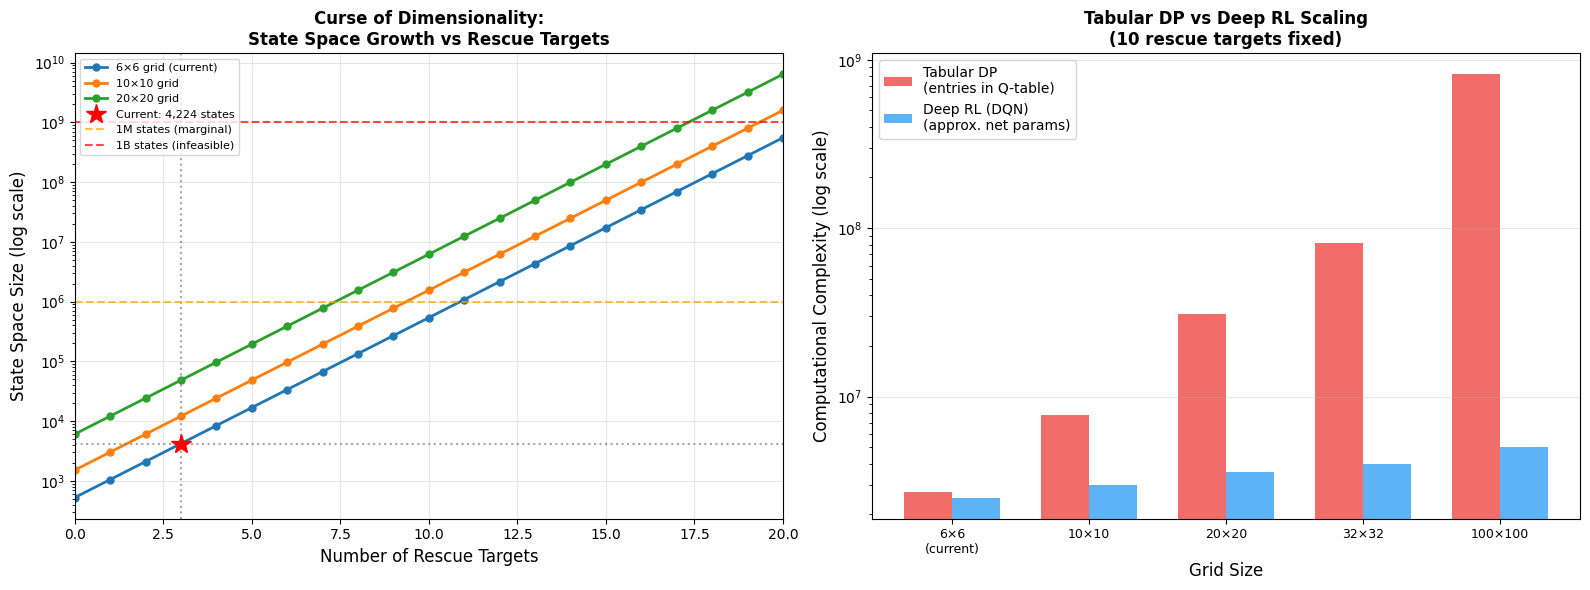

Saved: scalability_analysis.png


In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# SCALABILITY ANALYSIS: Visualise state space growth
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: State space growth vs number of rescue targets ─────────────────────
num_targets = list(range(0, 21))

# Three grid size scenarios
grid_configs = [
    (33,  '6×6 grid (current)'),
    (95,  '10×10 grid'),
    (380, '20×20 grid'),
]

for positions, label in grid_configs:
    state_counts = [positions * 16 * (2 ** n) for n in num_targets]
    axes[0].semilogy(num_targets, state_counts, 'o-', linewidth=2,
                     markersize=5, label=label)

# Mark current problem
current_count = 33 * 16 * 8
axes[0].axhline(y=current_count, color='grey', linestyle=':', alpha=0.7)
axes[0].axvline(x=3,             color='grey', linestyle=':', alpha=0.7)
axes[0].plot(3, current_count, 'r*', markersize=15, zorder=5, label=f'Current: {current_count:,} states')

# Feasibility thresholds
axes[0].axhline(y=1e6,  color='orange', linestyle='--', alpha=0.7, label='1M states (marginal)')
axes[0].axhline(y=1e9,  color='red',    linestyle='--', alpha=0.7, label='1B states (infeasible)')

axes[0].set_xlabel('Number of Rescue Targets', fontsize=12)
axes[0].set_ylabel('State Space Size (log scale)', fontsize=12)
axes[0].set_title('Curse of Dimensionality:\nState Space Growth vs Rescue Targets',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 20)

# ── Right: Comparison of DP vs Deep RL scaling ───────────────────────────────
problem_sizes = [33, 95, 380, 1000, 10000]
size_labels   = ['6×6\n(current)', '10×10', '20×20', '32×32', '100×100']
n_targets_fixed = 10   # Fix 10 rescue targets

# Tabular DP: memory scales as O(|S| × |A|)
dp_complexity   = [p * 16 * (2 ** n_targets_fixed) * 5 for p in problem_sizes]

# Deep RL (DQN): network params roughly constant (e.g. 1M params, fixed)
# Time scales sub-linearly with environment complexity (generalisation)
dqn_approx = [1e6 * (1 + np.log10(p)) for p in problem_sizes]  # Approximate

x = np.arange(len(problem_sizes))
w = 0.35

bars1 = axes[1].bar(x - w/2, dp_complexity,  width=w, label='Tabular DP\n(entries in Q-table)',
                    color='#EF5350', alpha=0.85)
bars2 = axes[1].bar(x + w/2, dqn_approx,     width=w, label='Deep RL (DQN)\n(approx. net params)',
                    color='#42A5F5', alpha=0.85)

axes[1].set_yscale('log')
axes[1].set_xticks(x)
axes[1].set_xticklabels(size_labels, fontsize=9)
axes[1].set_xlabel('Grid Size', fontsize=12)
axes[1].set_ylabel('Computational Complexity (log scale)', fontsize=12)
axes[1].set_title(f'Tabular DP vs Deep RL Scaling\n({n_targets_fixed} rescue targets fixed)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('scalability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scalability_analysis.png")

In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ──────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print("  ASSIGNMENT SUMMARY")
print("=" * 65)
print()
print("  Group ID      : 239")
print("  Register      : 2024ac05884  (seed = 202405884)")
print()
print("  MDP Configuration:")
print(f"    Grid         : {NROWS} × {NCOLS}")
print(f"    Max battery  : {MAX_BATTERY} units")
print(f"    Wind prob    : {int(WIND_PROB*100)}%")
print(f"    Max steps    : {MAX_STEPS}")
print(f"    Discount γ   : {GAMMA}")
print()
print("  State Space:")
print(f"    Total states      : {len(all_states):,}")
print(f"    Non-terminal      : {len(non_terminal_states):,}")
print(f"    Terminal          : {len(terminal_states):,}")
print()
print("  Value Iteration Results:")
print(f"    Convergence iters : {vi_iters}")
print(f"    Runtime           : {vi_elapsed:.4f} s")
print(f"    Final Δ           : {vi_final_delta:.2e}  (threshold θ = {THETA:.0e})")
print()
print("  Episode Performance (following π*):")
print(f"    Steps taken       : {len(trajectory) - 1}")
print(f"    Total reward      : {total_reward:.1f}")
print(f"    Termination       : {trajectory[-1]['info'].get('reason', 'unknown')}")
print(f"    Rescues completed : {bin(trajectory[-1]['mask']).count('1')}/{NUM_RESCUES}")
print()
print("  Output files generated:")
output_files = [
    'vi_convergence.png          — Value Iteration convergence curve',
    'policy_bat15_mask000.png    — Policy arrows: full battery, no rescues',
    'policy_bat4_mask000.png     — Policy arrows: low battery (charging urgency)',
    'policy_rescue_progression.png — Side-by-side: 3 rescue-progress slices',
    'trajectory.png              — Episode trajectory: path + battery/reward',
    'heatmap_bat15_mask000.png   — Primary V* heatmap',
    'heatmap_comparison.png      — 6-panel comparative heatmap',
    'value_vs_battery.png        — V* vs battery for key positions',
    'scalability_analysis.png    — DP vs Deep RL scaling comparison',
]
for f in output_files:
    print(f"    {f}")
print()
print("=" * 65)
print("  All sections complete.")
print("=" * 65)

  ASSIGNMENT SUMMARY

  Group ID      : 239
  Register      : 2024ac05884  (seed = 202405884)

  MDP Configuration:
    Grid         : 6 × 6
    Max battery  : 15 units
    Wind prob    : 30%
    Max steps    : 75
    Discount γ   : 0.99

  State Space:
    Total states      : 4,224
    Non-terminal      : 3,465
    Terminal          : 759

  Value Iteration Results:
    Convergence iters : 417
    Runtime           : 2.8568 s
    Final Δ           : 9.90e-04  (threshold θ = 1e-03)

  Episode Performance (following π*):
    Steps taken       : 75
    Total reward      : 153.0
    Termination       : max_steps_exceeded
    Rescues completed : 2/3

  Output files generated:
    vi_convergence.png          — Value Iteration convergence curve
    policy_bat15_mask000.png    — Policy arrows: full battery, no rescues
    policy_bat4_mask000.png     — Policy arrows: low battery (charging urgency)
    policy_rescue_progression.png — Side-by-side: 3 rescue-progress slices
    trajectory.png    